<a href="https://colab.research.google.com/github/vwendtUDC/Knee_or_ROC/blob/main/Compact_CCT_multiOb_val.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
%pip install tqdm

In [71]:
%matplotlib inline

import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import ToPILImage
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [72]:
#Converts a tensor image to the proper numpy format of (x, y, channels) from a format of (channels, x, y).
def im_transform(tensor):
    if tensor.shape[0]==3 or tensor.shape[0]==1:
      return tensor.permute(1,2,0).numpy()
    else:
      print('It seems this image is already formatted properly for numpy operations.')

#The concatenating image function for combining four images with four labels into a single grid-like image.
#For this the indices of images and the dataset they are from must be defined. It is optional to pull out
#The corresponding labels or to resize to other dimensions.
def concat_image(indices,dataset,labels=False,resizing=None):
    cc_img=np.zeros((64,64,3))
    cats=[]
    for i in range(4):
        temp_img=im_transform(dataset[indices[i]][0])
        cats.append(dataset[indices[i]][1])
        if i == 0:
            cc_img[0:32,0:32]=temp_img
        elif i == 1:
            cc_img[0:32,32:64]=temp_img
        elif i == 2:
            cc_img[32:64,0:32]=temp_img
        else:
            cc_img[32:64,32:64]=temp_img
    if resizing:
        from skimage.transform import resize
        try:
            cc_img=resize(cc_img,resizing)
        except:
            print('Make sure the resizing input is given as a tuple of the desired dimensions')
    if labels:
        return cc_img,tuple(cats)
    else:
        return cc_img

#Converts an image stored as a numpy array back to the proper format for saving the image through the PIL package.
def revert_np_image(im_array):
  tmp=ToTensor()(im_array)
  return ToPILImage()(tmp)

In [73]:
#This function generates random integers to use as indices for pulling images from the original database for concatenation.
#Inputs here are i_max, which is the total number of images in the original database,
#and iterations, which is the number of new images one plans to generate.
def rand_indices(i_max,iterations):
    from random import randint
    i_max=i_max-1
    indices=[]
    for i in range(iterations):
        i1=randint(0,i_max)
        i2=randint(0,i_max)
        while i2 == i1:
            i2=randint(0,i_max)
        i3=randint(0,i_max)
        while i3 == i2 or i3 == i1:
            i3=randint(0,i_max)
        i4=randint(0,i_max)
        while i4 == i3 or i4 == i2 or i4 == i1:
            i4=randint(0,i_max)
        indices.append(tuple([i1,i2,i3,i4]))
    return indices


#This function simply creates a new destination folder to dump the concatenated images.
#By default, this function will create a folder in the current directory unless otherwise specified.
def set_directories(directory=None):
  if not directory:
    directory='/temp_dir/'
  if directory[0]!='/':
    return print('Make sure you have a new folder properly formatted with a \"/\" at the beginning')
  else:
    import os
    cd=os.getcwd()
    target=cd+directory
    if not os.path.exists(target):
      os.makedirs(target)
    return target

#This function initializes a dataframe formatted to track the original indices
#that are randomized to specific concatenation of the original  pulled, their respective labels,
#and the new filenames saved within the new database.
def create_dataframe(num_entries,base_data):
  import pandas as pd
  import numpy as np
  dataframe=pd.DataFrame()
  dataframe['Indices']=rand_indices(len(base_data),num_entries)
  dataframe['Label_1']=np.zeros(num_entries,dtype=object)
  dataframe['Label_2']=np.zeros(num_entries,dtype=object)
  dataframe['Label_3']=np.zeros(num_entries,dtype=object)
  dataframe['Label_4']=np.zeros(num_entries,dtype=object)
  dataframe['Filename']=np.zeros(num_entries,dtype=object)
  return dataframe

#This function generates the entire database through the use of the prior functions.
#Only the size of the data base through num_entries and the original dataset need to be provided,
#and everything else will be initialized to a default value. It's recommended to input the image_dest
#and df_name as specific file destinations/final table name if generating multiple datasets.
def generate_data(num_entries,base_data,image_dest=None,resizing=None,dataframe=None,df_name=None):
  import os
  if not image_dest:
    image_dest=set_directories()
  else:
    image_dest=set_directories(image_dest)
  if not resizing:
    resizing=(32,32)
  if not dataframe:
    dataframe=create_dataframe(num_entries,base_data)
  if not df_name:
    df_name='concated_data.csv'

  from tqdm import tqdm

  for i in tqdm(range (num_entries),desc='Generating ... '):
    temp_ind=dataframe['Indices'][i]
    temp_im,labels=concat_image(temp_ind,base_data,labels=True,resizing=resizing)
    if num_entries > 100000:
      name=image_dest+f'{i+1:09d}'+'.jpg'
    else:
      name=image_dest+f'{i+1:06d}'+'.jpg'
    revert_np_image(temp_im).save(name)
    dataframe.at[i,'Filename']=name
    dataframe.at[i,'Label_1']=labels[0]
    dataframe.at[i,'Label_2']=labels[1]
    dataframe.at[i,'Label_3']=labels[2]
    dataframe.at[i,'Label_4']=labels[3]
    dataframe.to_csv(os.getcwd()+'/'+df_name)
  print('\nThe data table is saved to '+df_name+', and images are stored within '+image_dest+'.')
  return dataframe

In [74]:
def pic_label_show(image=None,labels=None,dataframe=None,predictions=False):
    if type(image)!=torch.Tensor:
      from PIL import Image
      if not labels:
        try:
          labels=dataframe.loc[dataframe['Filename']==image,'Labels'][1]
        except:
          return print('The image path could not be located. Operation has been aborted.')
      try:
        image=Image.open(image)
        image=ToTensor()(image)
      except:
        return print('The image input is formatted incorrectly. Either load in a tensor corresponding to the image or the correct file path.')
    cat_keys={
     0:'airplane',
    1:'automobile',
    2:'bird',
    3:'cat',
    4:'deer',
    5:'dog',
    6:'frog',
    7:'horse',
    8:'ship',
    9:'truck'
    }
    if image.shape[0]==3 or image.shape[0]==1:
      image=im_transform(image)
    x=image.shape[0]
    y=image.shape[1]
    fig, ax = plt.subplots()
    if len(labels)==1:
      label=cat_keys[labels]
      try:
        ax.imshow(image)
      except:
        return print("The image format may have been incorrect. Please make sure it is in the numpy image format of (x, y, channels)")
      plt.text(2,2,label,bbox=dict(facecolor='white'))
    else:
        if len(labels) % 4 != 0:
                print('Image does not appear square with four distinct quadrants.')
        elif not predictions:
          cats=[cat_keys[label] for label in labels]
          try:
            ax.imshow(image)
          except:
            return print("The image format may have been incorrect. Please make sure it is in the numpy image format of (x, y, channels)")
        for i in range(len(cats)):
          if i == 0:
            plt.text(2,2,cats[i],bbox=dict(facecolor='white'))
          elif i == 1:
            plt.text(2+int(x/2),2,cats[i],bbox=dict(facecolor='white'))
          elif i == 2:
            plt.text(2,2+int(y/2),cats[i],bbox=dict(facecolor='white'))
          else:
            plt.text(2+int(x/2),2+int(y/2),cats[i],bbox=dict(facecolor='white'))
    return None

In [75]:
# This cell code changed from FashionMNIST to CIFAR10

# Download training data from open datasets.
training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)


In [76]:
#using Labsign Data instead.
size_database=500
concat_data=generate_data(size_database,test_data,image_dest='/test/',df_name='test.csv')

Generating ... : 100%|██████████| 500/500 [00:03<00:00, 127.19it/s]


The data table is saved to test.csv, and images are stored within /content/test/.


In [77]:
####above code adds test/test.csv to directory for ease of access when using colab

##Zip and upload utils from https://github.com/SHI-Labs/Compact-Transformers/tree/main/src



In [78]:
%pip install timm

In [79]:
%pip install ipynb

In [80]:
%pip install kneed

In [81]:
%pip install torch torchvision torchaudio

In [82]:
!unzip utils.zip

Archive:  utils.zip
replace __MACOSX/._utils? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: __MACOSX/._utils        
replace utils/transformers.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: utils/transformers.py   
  inflating: __MACOSX/utils/._transformers.py  
 extracting: utils/__init__.py       
  inflating: __MACOSX/utils/.___init__.py  
  inflating: utils/tokenizer.py      
  inflating: __MACOSX/utils/._tokenizer.py  
  inflating: utils/embedder.py       
  inflating: __MACOSX/utils/._embedder.py  
  inflating: utils/stochastic_depth.py  
  inflating: __MACOSX/utils/._stochastic_depth.py  
  inflating: utils/helpers.py        
  inflating: __MACOSX/utils/._helpers.py  


In [83]:
%matplotlib inline

# Original Code from the SHI-Labs
# .utils in the from lines changed to utils
# .registry import changed to the function def (copied from the registry.py)

import torch
from torch.hub import load_state_dict_from_url
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from utils.transformers import TransformerClassifier
from utils.tokenizer import Tokenizer
from utils.helpers import pe_check, fc_check
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os
import kneed



In [84]:
try:
    from timm.models.registry import register_model
except ImportError:
    #from .registry import register_model
    def register_model(func):
      """
      Fallback wrapper in case timm isn't installed
      """
      return func

model_urls = {
    'cct_7_3x1_32':
        'https://shi-labs.com/projects/cct/checkpoints/pretrained/cct_7_3x1_32_cifar10_300epochs.pth'
}


class CCT(nn.Module):
    def __init__(self,
                 img_size=224,
                 embedding_dim=768,
                 n_input_channels=3,
                 n_conv_layers=1,
                 kernel_size=7,
                 stride=2,
                 padding=3,
                 pooling_kernel_size=3,
                 pooling_stride=2,
                 pooling_padding=1,
                 dropout=0.,
                 attention_dropout=0.1,
                 stochastic_depth=0.1,
                 num_layers=14,
                 num_heads=6,
                 mlp_ratio=4.0,
                 num_classes=1000,
                 positional_embedding='learnable',
                 *args, **kwargs):
        super(CCT, self).__init__()

        self.tokenizer = Tokenizer(n_input_channels=n_input_channels,
                                   n_output_channels=embedding_dim,
                                   kernel_size=kernel_size,
                                   stride=stride,
                                   padding=padding,
                                   pooling_kernel_size=pooling_kernel_size,
                                   pooling_stride=pooling_stride,
                                   pooling_padding=pooling_padding,
                                   max_pool=True,
                                   activation=nn.ReLU,
                                   n_conv_layers=n_conv_layers,
                                   conv_bias=False)

        self.classifier = TransformerClassifier(
            sequence_length=self.tokenizer.sequence_length(n_channels=n_input_channels,
                                                           height=img_size,
                                                           width=img_size),
            embedding_dim=embedding_dim,
            seq_pool=True,
            dropout=dropout,
            attention_dropout=attention_dropout,
            stochastic_depth=stochastic_depth,
            num_layers=num_layers,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            num_classes=num_classes,
            positional_embedding=positional_embedding
        )

    def forward(self, x):
        x = self.tokenizer(x)
        return self.classifier(x)


def _cct(arch, pretrained, progress,
         num_layers, num_heads, mlp_ratio, embedding_dim,
         kernel_size=3, stride=None, padding=None,
         positional_embedding='learnable',
         *args, **kwargs):
    stride = stride if stride is not None else max(1, (kernel_size // 2) - 1)
    padding = padding if padding is not None else max(1, (kernel_size // 2))
    model = CCT(num_layers=num_layers,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                embedding_dim=embedding_dim,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                *args, **kwargs)

    if pretrained:
        if arch in model_urls:
            state_dict = load_state_dict_from_url(model_urls[arch],
                                                  progress=progress)
            if positional_embedding == 'learnable':
                state_dict = pe_check(model, state_dict)
            elif positional_embedding == 'sine':
                state_dict['classifier.positional_emb'] = model.state_dict()['classifier.positional_emb']
            state_dict = fc_check(model, state_dict)
            model.load_state_dict(state_dict)
        else:
            raise RuntimeError(f'Variant {arch} does not yet have pretrained weights.')
    return model

def cct_7(arch, pretrained, progress, *args, **kwargs):
    return _cct(arch, pretrained, progress, num_layers=7, num_heads=4, mlp_ratio=2, embedding_dim=256,
                *args, **kwargs)
@register_model
def cct_7_3x1_32(pretrained=False, progress=False,
                 img_size=32, positional_embedding='learnable', num_classes=10,
                 *args, **kwargs):
    return cct_7('cct_7_3x1_32', pretrained, progress,
                 kernel_size=3, n_conv_layers=1,
                 img_size=img_size, positional_embedding=positional_embedding,
                 num_classes=num_classes,
                 *args, **kwargs)




<ipython-input-84-b9da9a27e70e>:107: UserWarning: Overwriting cct_7_3x1_32 in registry with __main__.cct_7_3x1_32. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


# New Section

##Modified the Workflow from the Quickstart Tutorial of PyTorch


[Learn the Basics](intro.html) ||
**Quickstart** ||
[Tensors](tensorqs_tutorial.html) ||
[Datasets & DataLoaders](data_tutorial.html) ||
[Transforms](transforms_tutorial.html) ||
[Build Model](buildmodel_tutorial.html) ||
[Autograd](autogradqs_tutorial.html) ||
[Optimization](optimization_tutorial.html) ||
[Save & Load Model](saveloadrun_tutorial.html)

# Quickstart
This section runs through the API for common tasks in machine learning. Refer to the links in each section to dive deeper.

## Working with data
PyTorch has two [primitives to work with data](https://pytorch.org/docs/stable/data.html):
``torch.utils.data.DataLoader`` and ``torch.utils.data.Dataset``.
``Dataset`` stores the samples and their corresponding labels, and ``DataLoader`` wraps an iterable around
the ``Dataset``.


PyTorch offers domain-specific libraries such as [TorchText](https://pytorch.org/text/stable/index.html),
[TorchVision](https://pytorch.org/vision/stable/index.html), and [TorchAudio](https://pytorch.org/audio/stable/index.html),
all of which include datasets. For this tutorial, we  will be using a TorchVision dataset.

The ``torchvision.datasets`` module contains ``Dataset`` objects for many real-world vision data like
CIFAR, COCO ([full list here](https://pytorch.org/vision/stable/datasets.html)). In this tutorial, we
use the FashionMNIST dataset. Every TorchVision ``Dataset`` includes two arguments: ``transform`` and
``target_transform`` to modify the samples and labels respectively.



We pass the ``Dataset`` as an argument to ``DataLoader``. This wraps an iterable over our dataset, and supports
automatic batching, sampling, shuffling and multiprocess data loading. Here we define a batch size of 64, i.e. each element
in the dataloader iterable will return a batch of 64 features and labels.



In [85]:
def im_transform(tensor):
    if tensor.shape[0]==3 or tensor.shape[0]==1:
      return tensor.permute(1,2,0).numpy()
    else:
      print('It seems this image is already formatted properly for numpy operations.')

def pic_label_show(image=None,labels=None,dataframe=None,predictions=False,save=False,file_dest=None):
    if type(image)!=torch.Tensor:
      if not labels:
        try:
          labels=dataframe.loc[dataframe['Filename']==image,'Labels'][1]
        except:
          return print('The image path could not be located. Operation has been aborted.')
      try:
        image=Image.open(image)
        image=ToTensor()(image)
      except:
        return print('The image input is formatted incorrectly. Either load in a tensor corresponding to the image or the correct file path.')
    cat_keys={
    0:'airplane',
    1:'automobile',
    2:'bird',
    3:'cat',
    4:'deer',
    5:'dog',
    6:'frog',
    7:'horse',
    8:'ship',
    9:'truck'
    }
    if image.shape[0]==3 or image.shape[0]==1:
      image=im_transform(image)
    x=image.shape[0]
    y=image.shape[1]
    fig, ax = plt.subplots()
    if len(labels)==1:
      label=cat_keys[labels]
      try:
        ax.imshow(image)
      except:
        return print("The image format may have been incorrect. Please make sure it is in the numpy image format of (x, y, channels)")
      plt.text(2,2,label,bbox=dict(facecolor='white'))
    else:
      if len(labels) % 4 != 0:
        return print('Image does not appear square with four distinct quadrants.')
      else:
        cats=[cat_keys[label] for label in labels]
      try:
        ax.imshow(image)
      except:
        return print("The image format may have been incorrect. Please make sure it is in the numpy image format of (x, y, channels)")
      if not predictions:
        for i in range(len(cats)):
          if i == 0:
            plt.text(2,2,cats[i],bbox=dict(facecolor='white'))
          elif i == 1:
            plt.text(2+int(x/2),2,cats[i],bbox=dict(facecolor='white'))
          elif i == 2:
            plt.text(2,2+int(y/2),cats[i],bbox=dict(facecolor='white'))
          else:
              plt.text(2+int(x/2),2+int(y/2),cats[i],bbox=dict(facecolor='white'))
      else:
        plt.text(0,1,'Possible matches of '+str(cats),bbox=dict(facecolor='white'))
    if save & isinstance(file_dest, str):
      fig.savefig(os.getcwd()+'/'+file_dest+'.png')
    return None


In [86]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]


## Load a model and Predict on a single input

In [87]:
model=cct_7_3x1_32(pretrained=True)


In [88]:
print(model)

CCT(
  (tokenizer): Tokenizer(
    (conv_layers): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): ReLU()
        (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      )
    )
    (flattener): Flatten(start_dim=2, end_dim=3)
  )
  (classifier): TransformerClassifier(
    (attention_pool): Linear(in_features=256, out_features=1, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (blocks): ModuleList(
      (0): TransformerEncoderLayer(
        (pre_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (self_attn): Attention(
          (qkv): Linear(in_features=256, out_features=768, bias=False)
          (attn_drop): Dropout(p=0.1, inplace=False)
          (proj): Linear(in_features=256, out_features=256, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=

In [89]:
def top4_preds(pred):
    list_convert=list(pred[0])
    num_list=[]
    for i in range(len(list_convert)):
        num_list.append(float(list_convert[i]))
    top4=[]
    for i in range(4):
        top4.append(num_list.index(max(num_list)))
        num_list[top4[i]]=-10
    return tuple(top4)

def image_to_pred(file,model):
    im=ToTensor()(Image.open(file))
    with torch.no_grad():
        im=im[None,:]
        pred=model(im)
    return pred

def labels_extract(db,col_names=None):
    if not col_names:
        col_names=['Label_1','Label_2','Label_3','Label_4']
    for i in range(len(col_names)):
        try:
            db[col_names[i]]
        except:
            print('The input database is not formatted correctly to extract labels')
    labels=[]
    for i in range(len(db.index)):
        temp=[]
        for j in range(len(col_names)):
            temp.append(db[col_names[j]][i])
        labels.append(tuple(temp))
    return labels

def images_and_labels(db,label_cols=None,file_col=None):
    if not label_cols:
        label_cols=['Label_1','Label_2','Label_3','Label_4']
    if not file_col:
        file_col='Filename'
    try:
        db[file_col]
    except:
        print('Make sure to input the correct column name for the image file paths.')
    for i in range(len(label_cols)):
        try:
            db[label_cols[i]]
        except:
            print('The input database is not formatted correctly to extract labels')

    files=list(mo_data[file_col])
    labels=labels_extract(db,label_cols)
    return files,labels

def acc_table(labels,predicted,col_names=None):
    if not col_names:
        col_names=['Actuals','Predictions','Num_matches']
    elif len(col_names) != 3:
        return print('This function only creates a table with 3 columns. Make sure only labels for 3 columns are included')
    acc_eval=pd.DataFrame()
    acc_eval[col_names[0]]=labels
    acc_eval[col_names[1]]=predicted
    tot_corr=[]
    for i in range(len(predicted)):
        num_corr=0
        for j in range(len(predicted[i])):
            if predicted[i][j] in labels[i]:
                num_corr+=1
        tot_corr.append(num_corr)
    acc_eval[col_names[2]]=tot_corr
    return acc_eval

def plot_correct_total(tot_corr,db,max_matches=4,match_col='Num_matches',x_title=None,y_title=None,plt_title=None,save=False,file_dest=None):
    num_preds=len(tot_corr)
    if not x_title:
        x_title='Correct matches for given prediction'
    if not y_title:
        y_title='Total number of correct matches'
    if not plt_title:
        plt_title='Distribution of correct matches for '+str(num_preds)+' multi-object predictions'
    fig,ax = plt.subplots()
    corr_cats=list(range(max_matches+1))
    counts=[]
    for i in corr_cats:
        counts.append(sum(db[match_col]==i))
    ax=plt.bar(corr_cats,counts)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(plt_title)
    plt.ylim(ymin=0,ymax=num_preds)
    for rect in ax:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2.0, height, f'{height:.0f}', ha='center', va='bottom')
    if save & isinstance(file_dest, str):
        fig.savefig(os.getcwd()+'/'+file_dest+'.png')

def plot_correct_prop(tot_corr,db,max_matches=4,match_col='Num_matches',x_title=None,y_title=None,plt_title=None,save=False,file_dest=None):
    num_preds=len(tot_corr)
    if not x_title:
        x_title='Correct matches for given prediction'
    if not y_title:
        y_title='Proportional number of correct matches (%)'
    if not plt_title:
        plt_title='Distribution of correct matches for '+str(num_preds)+' multi-object predictions'
    fig,ax = plt.subplots()
    corr_cats=list(range(max_matches+1))
    counts=[]
    for i in corr_cats:
        counts.append(sum(db[match_col]==i))
    prop_counts = [x / num_preds *100 for x in counts]
    ax=plt.bar(corr_cats,prop_counts)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(plt_title)
    plt.ylim(ymin=0,ymax=100)
    for rect in ax:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2.0, height, f'{height:.0f} %', ha='center', va='bottom')
    if save & isinstance(file_dest, str):
        fig.savefig(os.getcwd()+'/'+file_dest+'.png')




In [90]:
def gen_knees(preds,shape=None):
    if shape is None:
        shapes=[]
        for i in range(len(preds)):
            x=range(1,len(preds[i])+1)
            tmp=np.polyfit(x,preds[i],2)
            if tmp[0]<0:
                shapes.append('concave')
            else:
                shapes.append('convex')
    knee_val=[]
    for i in range(len(preds)):
        x=range(1,len(preds[i])+1)
        if shape is not None:
            kneedle=kneed.KneeLocator(x,preds[i],curve=shape,direction='decreasing')
        else:
            kneedle=kneed.KneeLocator(x,preds[i],curve=shapes[i],direction='decreasing')
        knee_val.append(kneedle.knee)
    for i in range(len(knee_val)):
        if knee_val[i] is None:
            knee_val[i]=1
    return knee_val

def plot_knees(preds,knee_val=None,shape=None,x_title=None,y_title=None,plt_title=None,assumption=None,save=False,file_dest=None):
    if not knee_val:
        if not shape:
            knee_val=gen_knees(preds)
        else:
            knee_val=gen_knees(preds,shape=shape)
    num_preds=len(preds)
    if not x_title:
        x_title='# of classes'
    if not y_title:
        y_title='Count of knee values per # of classes'
    if not plt_title:
        plt_title='Distribution of knee values for '+str(num_preds)+' multi-object predictions'
    fig,ax = plt.subplots()
    x=range(1,len(preds[0])+1)
    counts=list(np.zeros(len(preds[0])))
    for i in range(len(knee_val)):
        counts[knee_val[i]-1]+=1
    ax=plt.bar(x,counts)
    plt.xticks(range(1,len(counts)+1))
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(plt_title)
    plt.ylim(ymin=0,ymax=1.25*max(counts))
    if not shape:
        plt.annotate('Individually assessed convexity vs concavity',xy=(0.05,0.95),xycoords='axes fraction')
    else:
        plt.annotate('Assumption of all softmax outputs having '+shape+' shapes.',xy=(0.05,0.95),xycoords='axes fraction')
    for rect in ax:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2.0, height, f'{height:.0f}', ha='center', va='bottom')
    if save & isinstance(file_dest, str):
        fig.savefig(os.getcwd()+'/'+file_dest+'.png')


In [91]:
#test.csv is created by multiObjectDatasetGen1.ipynb using the labsign data
#for a better understanding of the data and how it is structured read that file as this file mainly deals with the CCT
mo_data=pd.read_csv(os.getcwd()+'/test.csv')

In [92]:
mo_data.shape

(500, 7)

In [93]:
files,labels=images_and_labels(mo_data)

In [94]:
from tqdm import tqdm

predicted=[]
for i in tqdm(range(len(files)), 'Predicting... '):
    predicted.append(image_to_pred(files[i],model))

Predicting... : 100%|██████████| 500/500 [00:37<00:00, 13.21it/s]


## Top 4 predictions

In [95]:
top_4_preds=[]
for i in range(len(predicted)):
    top_4_preds.append(top4_preds(predicted[i]))

In [96]:
#using .softmax() function to convert ouptputs into probabilities of classification
m = nn.Softmax(dim=1)
softmax_preds=[]
for i in range(len(predicted)):
    softmax_preds.append(m(predicted[i]))

In [97]:
#fills the list N_arr with all the false labels probability amount (populates no cat images)
N_arr=[]
amount=0
#filling false positive arr
for i in range(500):
    for j in range(10):
        if j in labels[i]:
            pass
            #donothing
        else:
            N_arr.append(softmax_preds[i][0][j].item())


In [98]:
P_arr=[]
#fills the list P_arr with all the true labels probability amount (populates cat images)
for i in range(500):
    for j in range(4):
        correct_label_index = labels[i][j]
        P_arr.append(softmax_preds[i][0][correct_label_index].item())


In [99]:
def num_corr(labels,predicted):
    tot_corr=[]
    for i in range(len(predicted)):
        num_corr=0
        for j in range(len(predicted[i])):
            if predicted[i][j] in labels[i]:
                num_corr+=1
        tot_corr.append(num_corr)
    return tot_corr

def total_num_of_pred(labels,predicted):
    tot_corr=[]
    total_num_of_corr = 0
    for i in range(len(predicted)):
        num_corr=0
        for j in range(len(predicted[i])):
            if predicted[i][j] in labels[i]:
                num_corr+=1
        tot_corr.append(num_corr)
        total_num_of_corr += num_corr
    return total_num_of_corr

In [100]:
total=total_num_of_pred(labels,top_4_preds)
corr_per_file = num_corr(labels,top_4_preds)
len(top_4_preds)

500

In [101]:
acc_eval=acc_table(labels,top_4_preds)

In [102]:
for i in range(500):
  print('correct labels: ', labels[i], 'for image number ',i)
  print('top 4 predicted labels: ', top_4_preds[i])

correct labels:  (np.int64(0), np.int64(9), np.int64(2), np.int64(0)) for image number  0
top 4 predicted labels:  (4, 2, 0, 6)
correct labels:  (np.int64(6), np.int64(9), np.int64(1), np.int64(5)) for image number  1
top 4 predicted labels:  (8, 6, 4, 9)
correct labels:  (np.int64(0), np.int64(1), np.int64(2), np.int64(0)) for image number  2
top 4 predicted labels:  (8, 0, 4, 2)
correct labels:  (np.int64(5), np.int64(1), np.int64(0), np.int64(3)) for image number  3
top 4 predicted labels:  (4, 2, 7, 3)
correct labels:  (np.int64(0), np.int64(0), np.int64(3), np.int64(7)) for image number  4
top 4 predicted labels:  (4, 9, 0, 3)
correct labels:  (np.int64(7), np.int64(9), np.int64(0), np.int64(2)) for image number  5
top 4 predicted labels:  (4, 8, 6, 9)
correct labels:  (np.int64(8), np.int64(3), np.int64(8), np.int64(3)) for image number  6
top 4 predicted labels:  (8, 4, 3, 6)
correct labels:  (np.int64(6), np.int64(3), np.int64(6), np.int64(6)) for image number  7
top 4 predicte

In [103]:
acc_eval

,Actuals,Predictions,Num_matches
0,"(0, 9, 2, 0)","(4, 2, 0, 6)",2
1,"(6, 9, 1, 5)","(8, 6, 4, 9)",2
2,"(0, 1, 2, 0)","(8, 0, 4, 2)",2
3,"(5, 1, 0, 3)","(4, 2, 7, 3)",1
4,"(0, 0, 3, 7)","(4, 9, 0, 3)",2
...,...,...,...
495,"(2, 6, 5, 3)","(4, 3, 6, 5)",3
496,"(6, 4, 7, 2)","(2, 6, 4, 7)",4
497,"(5, 6, 5, 9)","(4, 0, 9, 7)",1
498,"(2, 0, 5, 3)","(4, 3, 2, 0)",3


In [104]:
acc_eval.head()

,Actuals,Predictions,Num_matches
0,"(0, 9, 2, 0)","(4, 2, 0, 6)",2
1,"(6, 9, 1, 5)","(8, 6, 4, 9)",2
2,"(0, 1, 2, 0)","(8, 0, 4, 2)",2
3,"(5, 1, 0, 3)","(4, 2, 7, 3)",1
4,"(0, 0, 3, 7)","(4, 9, 0, 3)",2


(array([ 16.,   0., 132.,   0.,   0., 233.,   0., 113.,   0.,   6.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

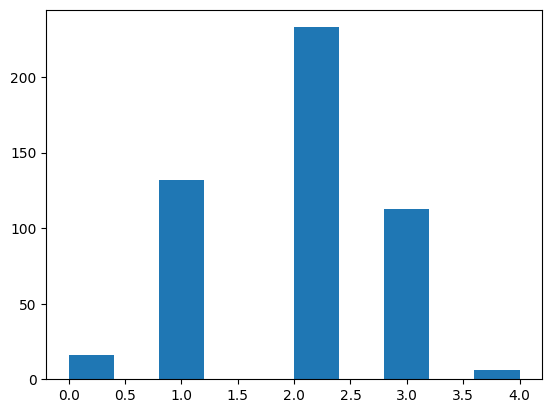

In [105]:
plt.hist(acc_eval['Num_matches'])

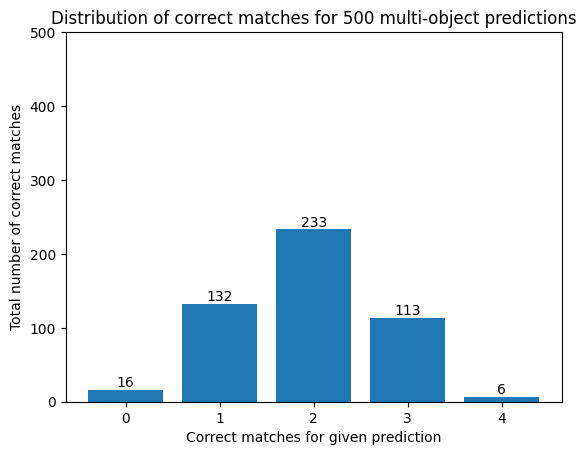

In [106]:
plot_correct_total(acc_eval,acc_eval)

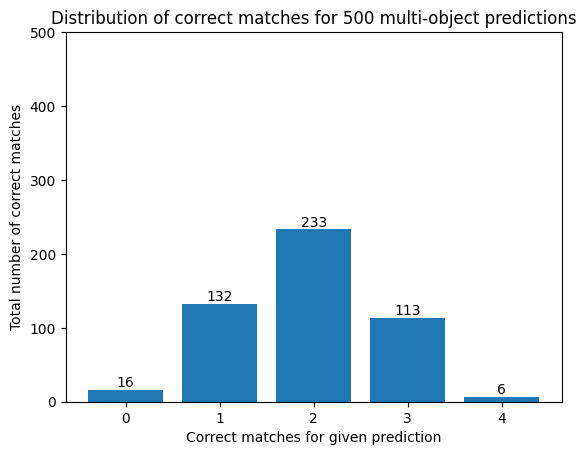

In [107]:
figure=plot_correct_total(acc_eval['Num_matches'],acc_eval,save=False,file_dest='corr_matches_500')

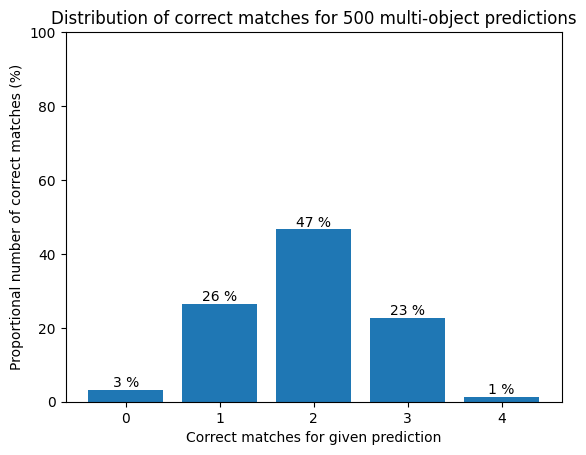

In [108]:
plot_correct_prop(acc_eval['Num_matches'],acc_eval,save=False,file_dest='prop_corr_matches_500')

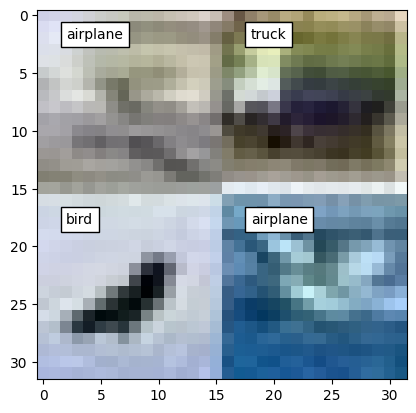

In [109]:
ax1=pic_label_show(image=files[0],labels=labels[0],save=False,file_dest='SampleImage_actual')

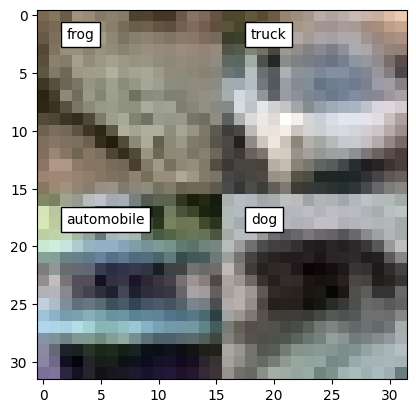

In [110]:
ax1=pic_label_show(image=files[1],labels=labels[1],save=False,file_dest='SampleImage_actual')

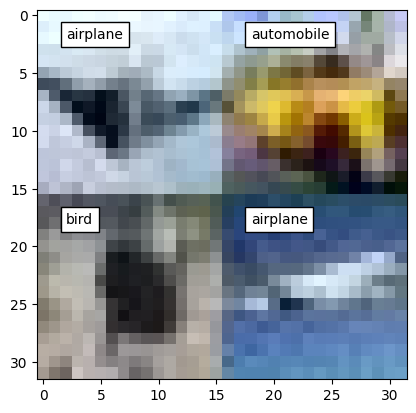

In [111]:
ax1=pic_label_show(image=files[2],labels=labels[2],save=False,file_dest='SampleImage_actual')

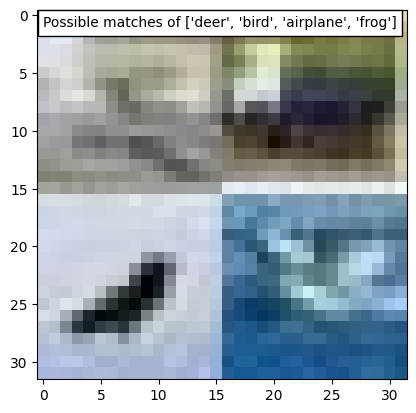

In [112]:
ax2=pic_label_show(image=files[0],labels=top_4_preds[0],predictions=True,save=False,file_dest='Sample_image_preds')

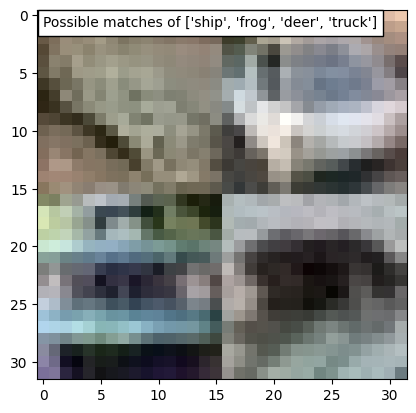

In [113]:
ax2=pic_label_show(image=files[1],labels=top_4_preds[1],predictions=True,save=False,file_dest='Sample_image_preds')

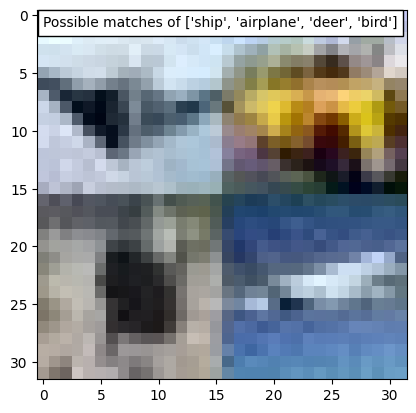

In [114]:
ax2=pic_label_show(image=files[2],labels=top_4_preds[2],predictions=True,save=False,file_dest='Sample_image_preds')

## Knee value calculations

In [115]:
all_preds=[]
for i in range(len(predicted)):
    pred_array=predicted[i].numpy()
    temp=[]
    for j in range(pred_array.shape[1]):
        temp.append(pred_array[0][j])
    all_preds.append(temp)

In [116]:
for i in range(len(all_preds)):
    all_preds[i]=sorted(all_preds[i],reverse=True)

In [117]:
knee_val_no_assumption=gen_knees(all_preds)
knee_val_concave=gen_knees(all_preds,shape='concave')
knee_val_convex=gen_knees(all_preds,shape='convex')

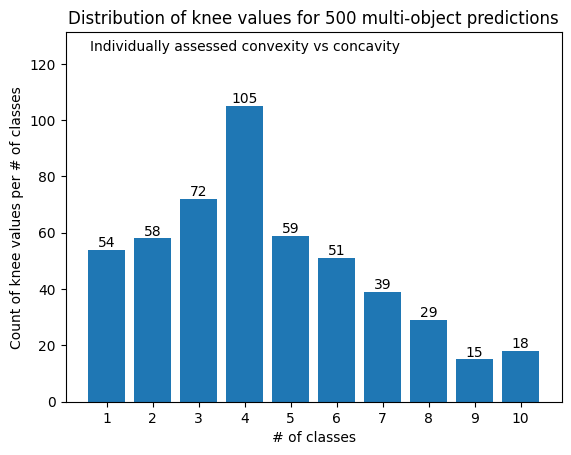

In [118]:
plot_knees(all_preds,knee_val=knee_val_no_assumption,save=False,file_dest='knee_val_500')

In [119]:
init=np.zeros(25000)

In [120]:
counts=[415,0,173,275,518,910,1577,5618,5176,13338]
index1=0
index2=0
for i in range(len(counts)):
    if i ==0:
        index2+=counts[i]
        init[index1:index2]=1
    else:
        index1+=counts[i-1]+1
        index2+=counts[i]+1
        init[index1:index2]=i+1

In [121]:
print(str(np.mean(init)))
print(str(np.std(init)))

8.63764
1.7417506223337482


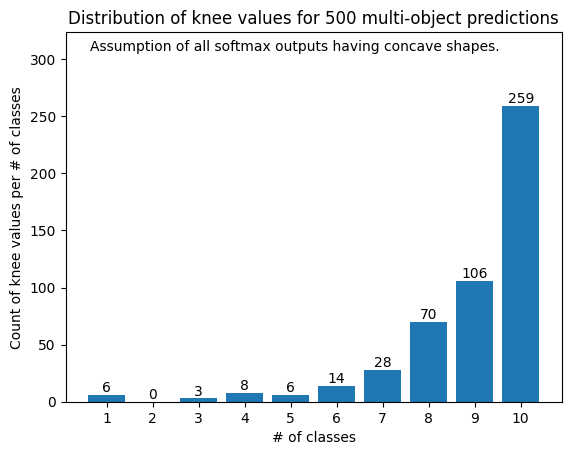

In [122]:
plot_knees(all_preds,knee_val=knee_val_concave,shape='concave',save=False,file_dest='knee_val_500_concave')

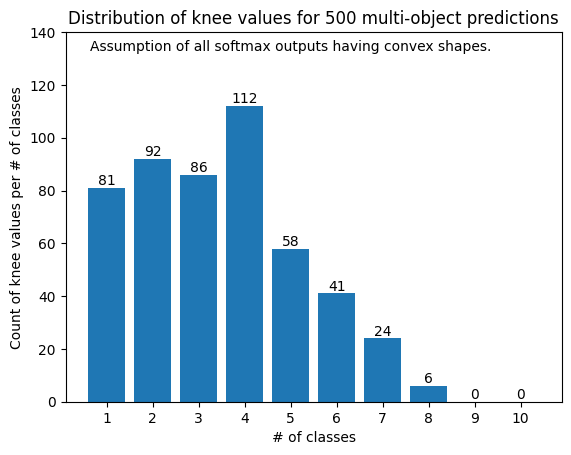

In [123]:
plot_knees(all_preds,knee_val=knee_val_convex,shape='convex',save=False,file_dest='knee_val_500_convex')

In [124]:
############################################################################################
#BELOW IS CODE USED TO GET CDF WHICH IS USED TO GET THE TPR AND FPR COORDINATES TO PLOT ROC#
############################################################################################

In [125]:
import math
import statistics as stat
#CDF formula calls for 1/2(1+ERF(x-mean/std*sqrt(2)))
#gets the fraction portion that needs to be ran through ERF
def get_x_erf(mean, std, x):
    res = 0
    num = x - mean
    den = std * math.sqrt(2)
    res = num / den
    return res

#math.erf() is called to give us a value that is then plugged into this which gives us the final CDF value
def cdf(erf):
    result = (1 + erf) * .5
    return result

#this function repopulates array 1 and 2 based on a new threshold of t
def new_t_val(arr1, arr2, t):
  #TRUE POSITIVES THOSE IN ARRAY 1 WITH A VALUE >= THE THRESHOLD
    newarr1=[]
  #FALSE POSITIVES THOSE IN ARRAY 2 WITH A VALUE >= THRESHOLD
    newarr2=[]
  #FALSE NEGATIVES THOSE IN ARRAY 1 WITH A VALUE < THRESHOLD
    newarr3=[]
  #TRUE NEGATIVES THOSE IN ARRAY 2 WITH A VALUE < THRESHOLD
    newarr4=[]
    '''
    for i in range(len(arr2)):
        newarr2.append(arr2[i])
    '''

    for i in range(len(arr1)):
        if arr1[i] < t:
            newarr3.append(arr1[i])
        else:
            newarr1.append(arr1[i])

    for i in range(len(arr2)):
        if arr2[i] < t:
            newarr4.append(arr2[i])
        else:
            newarr2.append(arr2[i])

    return newarr1,newarr2,newarr3,newarr4

#this function gets the coordinates of a TPR/FPR with the value of T increasing from .05 in intervals of .05
def getcoord(avg,std):
    coords=[]
    x = get_x_erf(avg,std,9999)
    erf = math.erf(x)
    cdf1 = cdf(erf)
    i = 0.05
    while i <= 1:
        y = get_x_erf(avg,std,i)
        erf2 = math.erf(y)
        cdf2 = cdf(erf2)
        coords.append(cdf1-cdf2)
        i += 0.05
    return coords
#gets the average of a list
def getavg(arr):
    total = 0
    for x in arr:
        total+=x
    average = total / len(arr)
    return average
#gets the STD of a list
def getstd(arr):
    x = stat.pstdev(arr)
    return x

#this function will take a TParr and FParr and go through the full process required to plot a ROC curve and finally plotting the ROC
#this function includes a parameter 'i' i is the new threshold to redefine arr1 and arr2
#this basically takes TParr and FParry and plots the ROC based on results all in one function
#but includes the option to repopulate array using
#new_t_val function see above for clarification
def method_2_through(arr1,arr2,i):

    newarr1=[]
    newarr2=[]
    newarr3=[]
    newarr4=[]

    print('THRESHOLD OF:', i)
    print('arr1:',len(arr1))
    print('arr2:',len(arr2))
    newarr1, newarr2, newarr3, newarr4 = new_t_val(arr1,arr2,i)
    print('newarr1:',len(newarr1))
    print('newarr2:', len(newarr2))
    print('newarr3:',len(newarr3))
    print('newarr4:', len(newarr4))
    #newavg1 = getavg(newarr1)
    #newstd1 = getstd(newarr1)
    new_avg1 = getavg(newarr1+newarr2)
    newstd1 = getstd(newarr1+newarr2)
    coord1 = getcoord(newavg1,newstd1)
    #newavg2 = getavg(newarr2)
    #newstd2 = getstd(newarr2)
    newavg2 = getavg(newarr3+newarr4)
    newstd2 = getstd(newarr3+newarr4)
    coord2 = getcoord(newavg2,newstd2)
    print('newavg1=', newavg1, ' newstd1=', newstd1)
    print('newavg2=', newavg2, ' newstd2=', newstd2)
    print('TP-FP =', sum(coord1)-sum(coord2))
    #coord2 is FP on X-axis, coord1 is TP on Y-axis
    plt.scatter(coord2,coord1)
    plt.plot(coord2,coord1)
    plt.show()



In [126]:
#populating a1
A1=[]
for i in range(2000):
    A1.append(P_arr[i])


#populating a2
A2=[]
total2 = 0
for i in range(len(N_arr)):
    A2.append(N_arr[i])

In [127]:
#getting total value for A1 and A2
total = 0
for i in range(2000):
    total += A1[i]

total1 = 0
for i in range(500):
    total1 += A2[i]

In [128]:
newarr1 = A1
newarr2 = A2
print(len(A2))
print(len(A1))

3282
2000


THRESHOLD OF: 0.01
arr1: 2000
arr2: 3282
newarr1: 1991
newarr2: 3223
newarr3: 9
newarr4: 59
newavg1= 0.1451243360056542  newstd1= 0.12039625367374407
newavg2= 0.008637311005526605  newstd2= 0.00108705266127168
TP-FP = 2.599772032146909


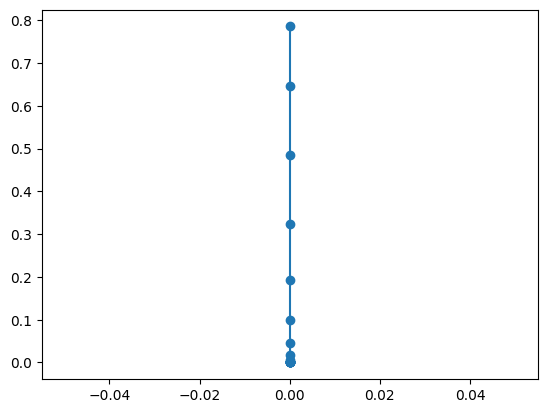

THRESHOLD OF: 0.02
arr1: 2000
arr2: 3282
newarr1: 1888
newarr2: 2702
newarr3: 112
newarr4: 580
newavg1= 0.1451243360056542  newstd1= 0.12316792385436039
newavg2= 0.014783146158614428  newstd2= 0.0033503326464465666
TP-FP = 2.6133689298012506


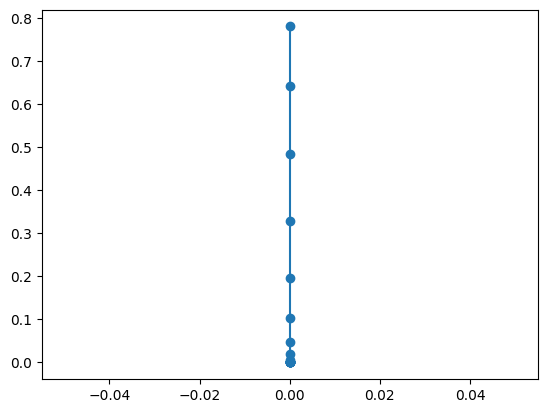

THRESHOLD OF: 0.03
arr1: 2000
arr2: 3282
newarr1: 1717
newarr2: 2151
newarr3: 283
newarr4: 1131
newavg1= 0.1451243360056542  newstd1= 0.1265492609252968
newavg2= 0.01988300663067352  newstd2= 0.005893774046877687
TP-FP = 2.6303590985543197


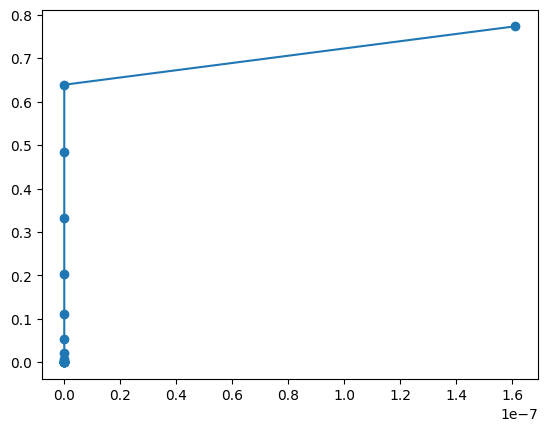

THRESHOLD OF: 0.04
arr1: 2000
arr2: 3282
newarr1: 1560
newarr2: 1774
newarr3: 440
newarr4: 1508
newavg1= 0.1451243360056542  newstd1= 0.12899099143052714
newavg2= 0.02401472902063135  newstd2= 0.008518944843083581
TP-FP = 2.6417473049234794


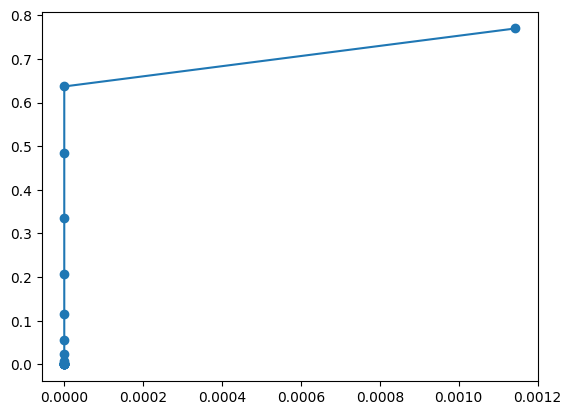

THRESHOLD OF: 0.05
arr1: 2000
arr2: 3282
newarr1: 1428
newarr2: 1463
newarr3: 572
newarr4: 1819
newavg1= 0.1451243360056542  newstd1= 0.130770133676089
newavg2= 0.027872784449615672  newstd2= 0.011226350522377321
TP-FP = 2.6277921552566754


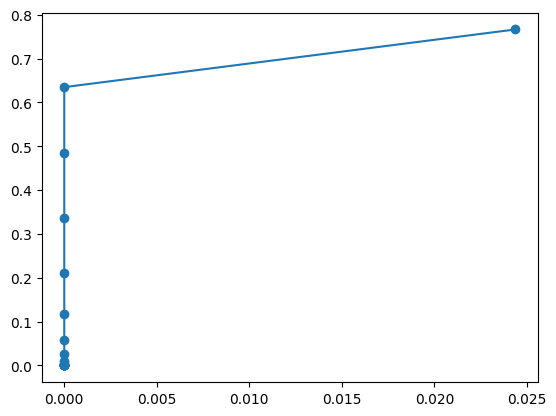

THRESHOLD OF: 0.060000000000000005
arr1: 2000
arr2: 3282
newarr1: 1308
newarr2: 1239
newarr3: 692
newarr4: 2043
newavg1= 0.1451243360056542  newstd1= 0.13179562236319975
newavg2= 0.03126034955042917  newstd2= 0.01381932124215331
TP-FP = 2.5699998991008997


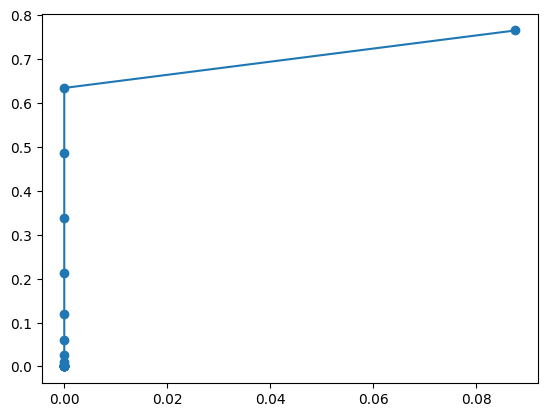

THRESHOLD OF: 0.07
arr1: 2000
arr2: 3282
newarr1: 1214
newarr2: 1060
newarr3: 786
newarr4: 2222
newavg1= 0.1451243360056542  newstd1= 0.13219662542858446
newavg2= 0.034269923357258335  newstd2= 0.01628384829773521
TP-FP = 2.4926080263762107


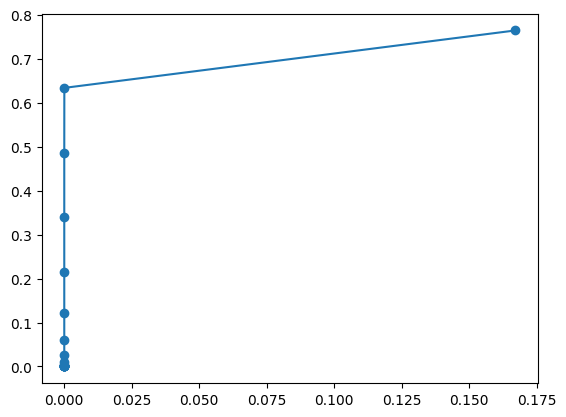

THRESHOLD OF: 0.08
arr1: 2000
arr2: 3282
newarr1: 1121
newarr2: 919
newarr3: 879
newarr4: 2363
newavg1= 0.1451243360056542  newstd1= 0.13214069756015173
newavg2= 0.037183746799509476  newstd2= 0.01886185407914265
TP-FP = 2.410512958415575


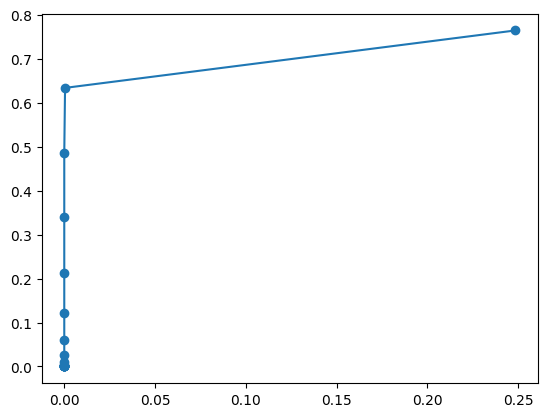

THRESHOLD OF: 0.09
arr1: 2000
arr2: 3282
newarr1: 1046
newarr2: 811
newarr3: 954
newarr4: 2471
newavg1= 0.1451243360056542  newstd1= 0.1317030447079616
newavg2= 0.03971129853631893  newstd2= 0.021223234062149945
TP-FP = 2.340889013601785


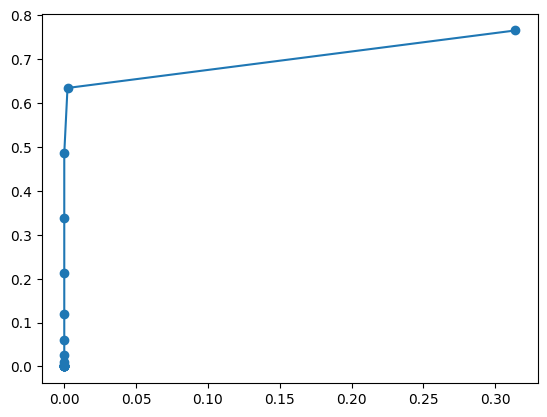

THRESHOLD OF: 0.09999999999999999
arr1: 2000
arr2: 3282
newarr1: 967
newarr2: 730
newarr3: 1033
newarr4: 2552
newavg1= 0.1451243360056542  newstd1= 0.13100503178542805
newavg2= 0.04216903292702581  newstd2= 0.02366409072412287
TP-FP = 2.2757643663934073


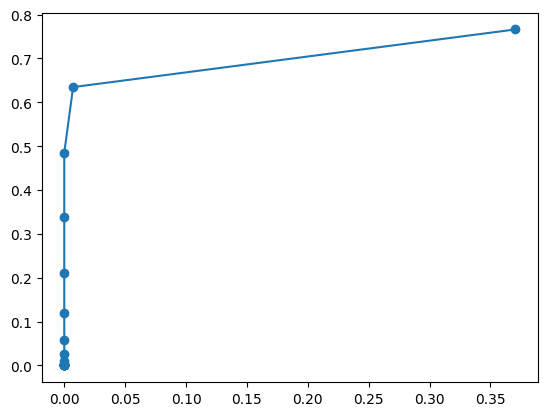

THRESHOLD OF: 0.10999999999999999
arr1: 2000
arr2: 3282
newarr1: 916
newarr2: 638
newarr3: 1084
newarr4: 2644
newavg1= 0.1451243360056542  newstd1= 0.13003489927809977
newavg2= 0.044580210534388064  newstd2= 0.02616481565613148
TP-FP = 2.213251058496306


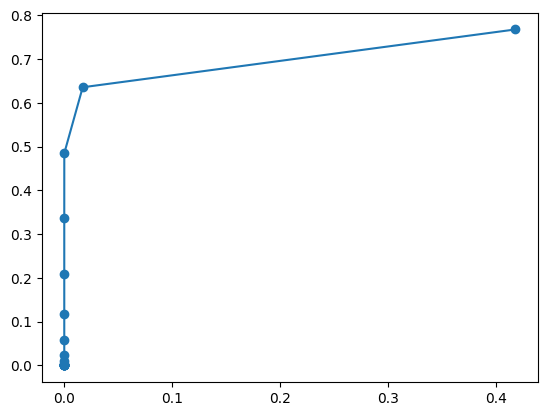

THRESHOLD OF: 0.11999999999999998
arr1: 2000
arr2: 3282
newarr1: 870
newarr2: 576
newarr3: 1130
newarr4: 2706
newavg1= 0.1451243360056542  newstd1= 0.1290476399761574
newavg2= 0.04656106002319981  newstd2= 0.02830150454816567
TP-FP = 2.1619123026832416


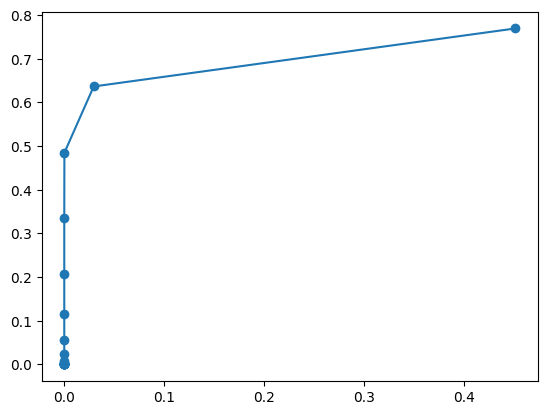

THRESHOLD OF: 0.12999999999999998
arr1: 2000
arr2: 3282
newarr1: 824
newarr2: 527
newarr3: 1176
newarr4: 2755
newavg1= 0.1451243360056542  newstd1= 0.1280402647096712
newavg2= 0.04845477039284892  newstd2= 0.03044030685465955
TP-FP = 2.1126058413025426


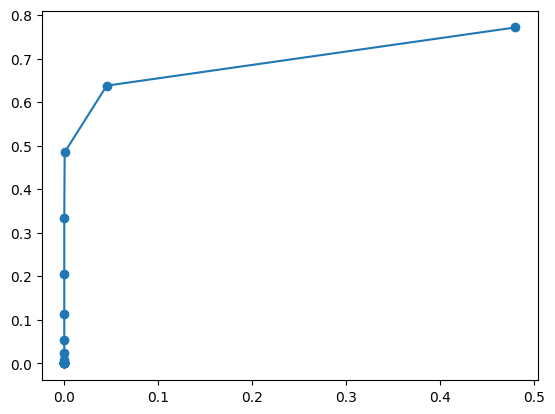

THRESHOLD OF: 0.13999999999999999
arr1: 2000
arr2: 3282
newarr1: 767
newarr2: 470
newarr3: 1233
newarr4: 2812
newavg1= 0.1451243360056542  newstd1= 0.12646742693882493
newavg2= 0.050883978850706696  newstd2= 0.03322869143746263
TP-FP = 2.0482120188907293


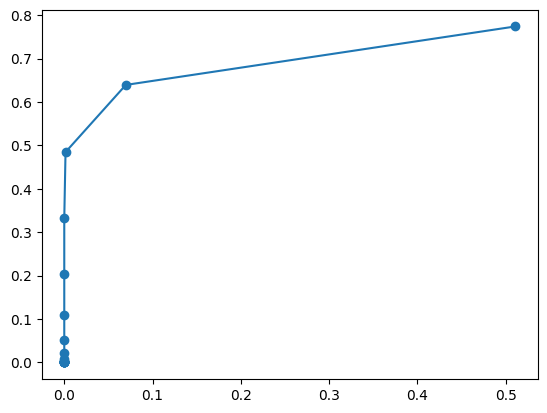

THRESHOLD OF: 0.15
arr1: 2000
arr2: 3282
newarr1: 725
newarr2: 429
newarr3: 1275
newarr4: 2853
newavg1= 0.1451243360056542  newstd1= 0.12496264030850107
newavg2= 0.05276303254510095  newstd2= 0.0354145311558061
TP-FP = 1.9970742414381883


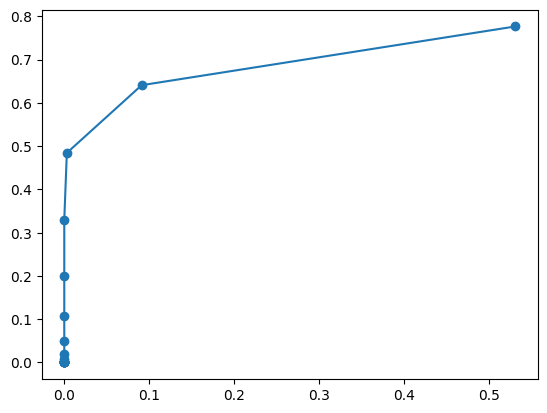

THRESHOLD OF: 0.16
arr1: 2000
arr2: 3282
newarr1: 688
newarr2: 387
newarr3: 1312
newarr4: 2895
newavg1= 0.1451243360056542  newstd1= 0.12337185209089042
newavg2= 0.054691092035681586  newstd2= 0.037749528036510764
TP-FP = 1.9440635027511026


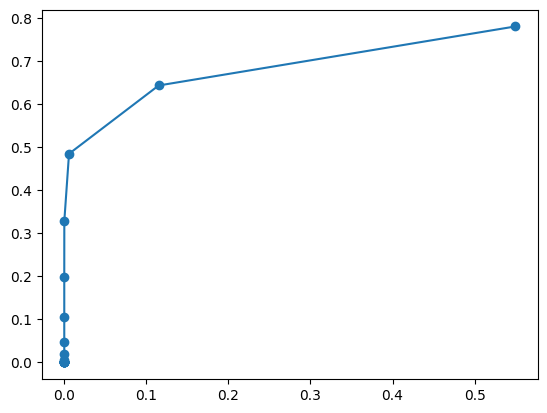

THRESHOLD OF: 0.17
arr1: 2000
arr2: 3282
newarr1: 650
newarr2: 351
newarr3: 1350
newarr4: 2931
newavg1= 0.1451243360056542  newstd1= 0.1216200769013951
newavg2= 0.056608715347199065  newstd2= 0.040119778791463855
TP-FP = 1.890453162721422


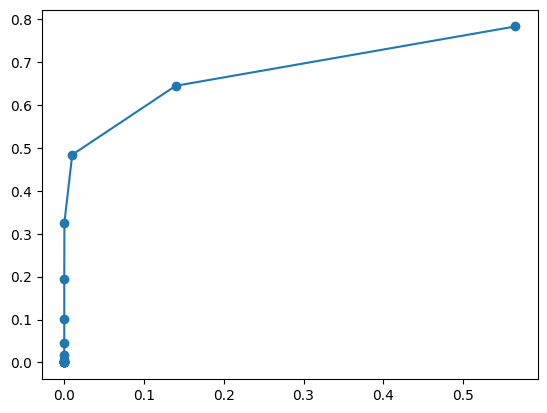

THRESHOLD OF: 0.18000000000000002
arr1: 2000
arr2: 3282
newarr1: 616
newarr2: 321
newarr3: 1384
newarr4: 2961
newavg1= 0.1451243360056542  newstd1= 0.11976852616583109
newavg2= 0.058346355097289054  newstd2= 0.04228465932687345
TP-FP = 1.8407016710754598


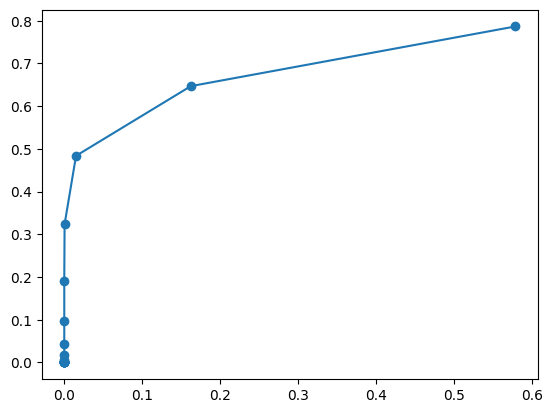

THRESHOLD OF: 0.19000000000000003
arr1: 2000
arr2: 3282
newarr1: 589
newarr2: 290
newarr3: 1411
newarr4: 2992
newavg1= 0.1451243360056542  newstd1= 0.11791122898229785
newavg2= 0.06001565789212876  newstd2= 0.0444217669968834
TP-FP = 1.792401883502495


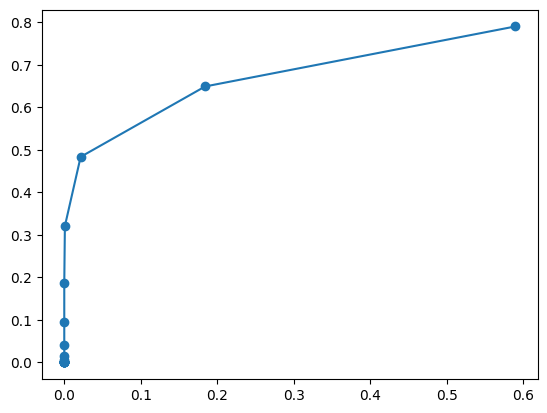

THRESHOLD OF: 0.20000000000000004
arr1: 2000
arr2: 3282
newarr1: 565
newarr2: 268
newarr3: 1435
newarr4: 3014
newavg1= 0.1451243360056542  newstd1= 0.11630452234845082
newavg2= 0.061408129315777264  newstd2= 0.04624465864127952
TP-FP = 1.751767042160913


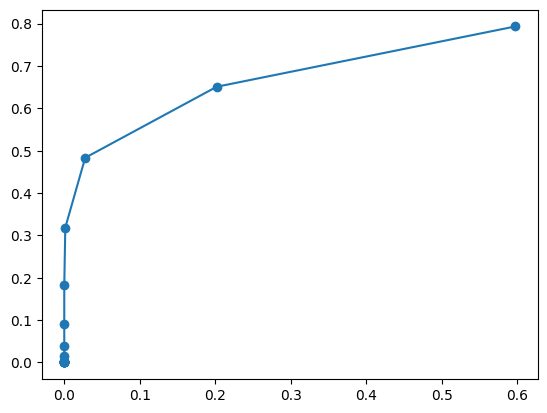

THRESHOLD OF: 0.21000000000000005
arr1: 2000
arr2: 3282
newarr1: 534
newarr2: 249
newarr3: 1466
newarr4: 3033
newavg1= 0.1451243360056542  newstd1= 0.11448983695575984
newavg2= 0.06300564988193962  newstd2= 0.04839426409488816
TP-FP = 1.7051226463151314


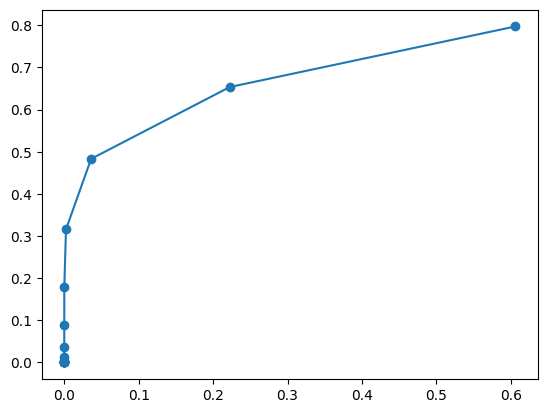

THRESHOLD OF: 0.22000000000000006
arr1: 2000
arr2: 3282
newarr1: 498
newarr2: 233
newarr3: 1502
newarr4: 3049
newavg1= 0.1451243360056542  newstd1= 0.11233082142622522
newavg2= 0.06473896394816696  newstd2= 0.05074722908432073
TP-FP = 1.6537562438161422


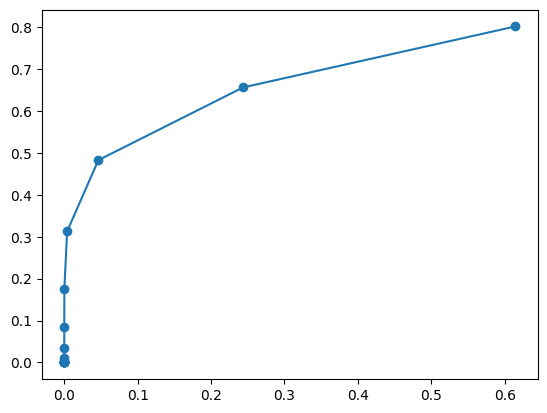

THRESHOLD OF: 0.23000000000000007
arr1: 2000
arr2: 3282
newarr1: 480
newarr2: 218
newarr3: 1520
newarr4: 3064
newavg1= 0.1451243360056542  newstd1= 0.11090788075232147
newavg2= 0.06589377073881526  newstd2= 0.05235178884230056
TP-FP = 1.6195301748489888


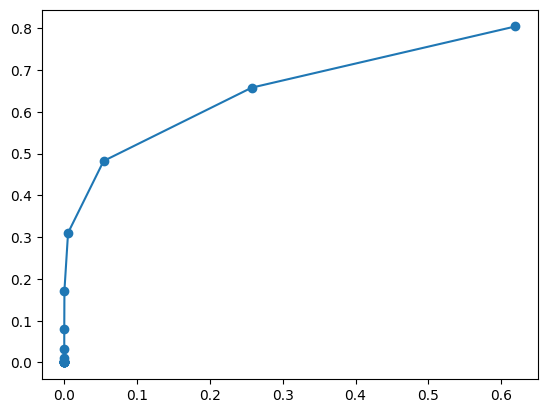

THRESHOLD OF: 0.24000000000000007
arr1: 2000
arr2: 3282
newarr1: 455
newarr2: 207
newarr3: 1545
newarr4: 3075
newavg1= 0.1451243360056542  newstd1= 0.10941654170224116
newavg2= 0.06721587140975899  newstd2= 0.05424010080553104
TP-FP = 1.580782474516


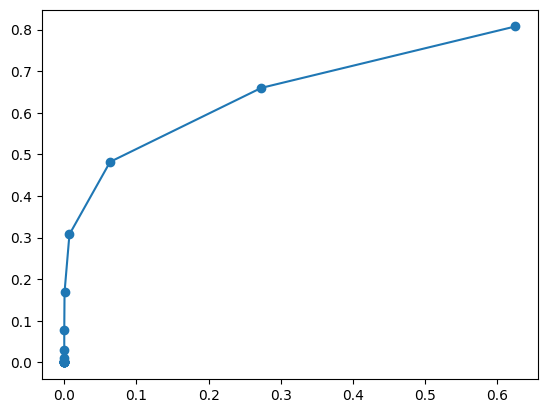

THRESHOLD OF: 0.25000000000000006
arr1: 2000
arr2: 3282
newarr1: 444
newarr2: 192
newarr3: 1556
newarr4: 3090
newavg1= 0.1451243360056542  newstd1= 0.10837645432457851
newavg2= 0.0682103631623471  newstd2= 0.05568946202437549
TP-FP = 1.5519015999700319


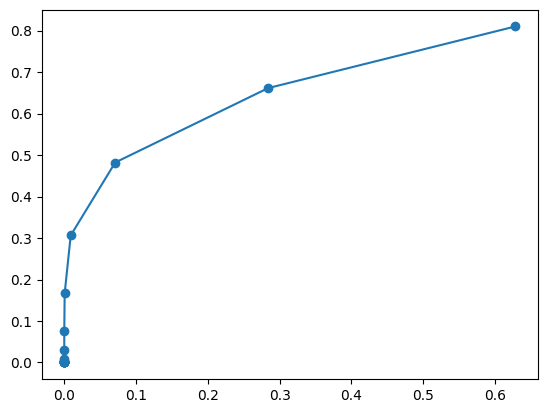

THRESHOLD OF: 0.26000000000000006
arr1: 2000
arr2: 3282
newarr1: 416
newarr2: 172
newarr3: 1584
newarr4: 3110
newavg1= 0.1451243360056542  newstd1= 0.10632922476825944
newavg2= 0.07011113486172965  newstd2= 0.05847558760973348
TP-FP = 1.4965389863802527


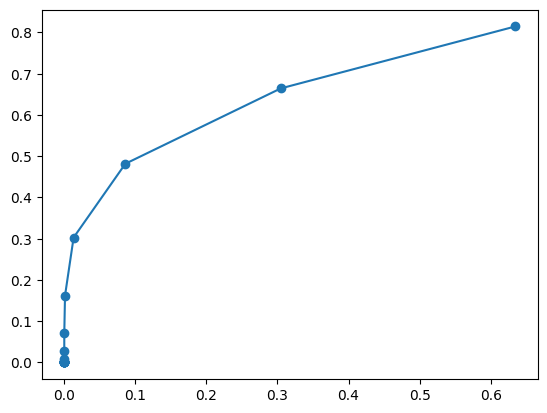

THRESHOLD OF: 0.2700000000000001
arr1: 2000
arr2: 3282
newarr1: 390
newarr2: 156
newarr3: 1610
newarr4: 3126
newavg1= 0.1451243360056542  newstd1= 0.1042912377812906
newavg2= 0.07183926997311425  newstd2= 0.06101557409480283
TP-FP = 1.4456580318595251


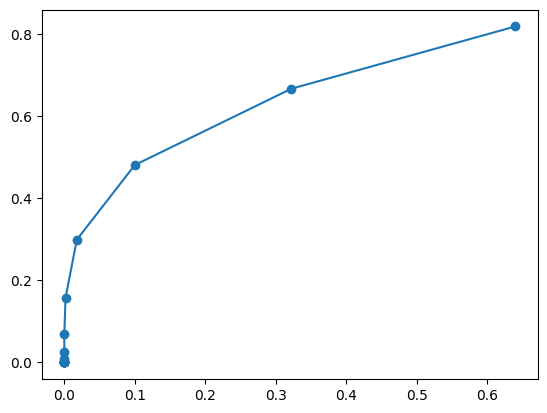

THRESHOLD OF: 0.2800000000000001
arr1: 2000
arr2: 3282
newarr1: 362
newarr2: 144
newarr3: 1638
newarr4: 3138
newavg1= 0.1451243360056542  newstd1= 0.10194625488597049
newavg2= 0.07353520156133926  newstd2= 0.06350054912127365
TP-FP = 1.394640774774035


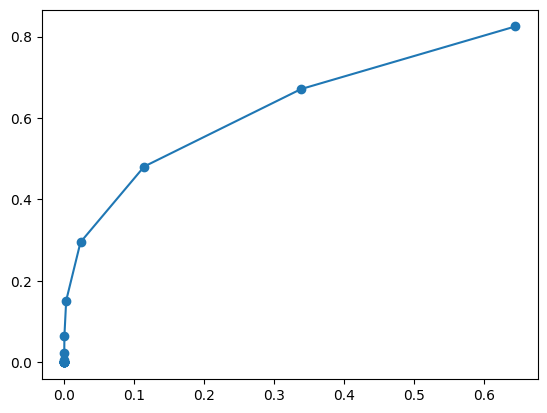

THRESHOLD OF: 0.2900000000000001
arr1: 2000
arr2: 3282
newarr1: 335
newarr2: 131
newarr3: 1665
newarr4: 3151
newavg1= 0.1451243360056542  newstd1= 0.09908873947797611
newavg2= 0.07528576073414674  newstd2= 0.06606637885888539
TP-FP = 1.3406510236709024


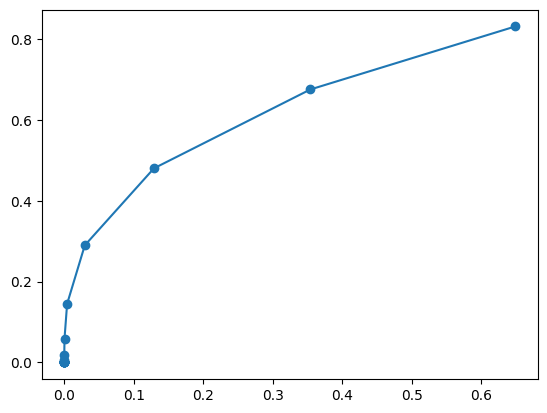

THRESHOLD OF: 0.3000000000000001
arr1: 2000
arr2: 3282
newarr1: 321
newarr2: 121
newarr3: 1679
newarr4: 3161
newavg1= 0.1451243360056542  newstd1= 0.09725510439724837
newavg2= 0.07637825669097321  newstd2= 0.06769534795228652
TP-FP = 1.3068541582281077


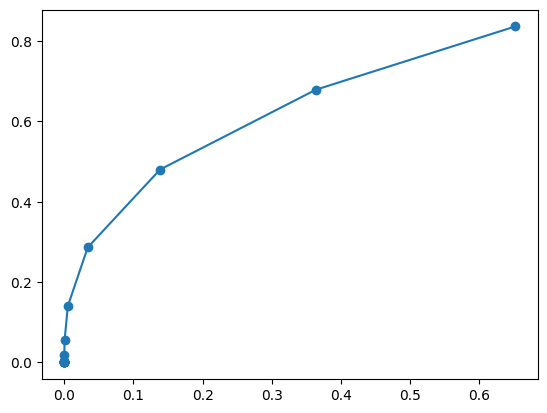

THRESHOLD OF: 0.3100000000000001
arr1: 2000
arr2: 3282
newarr1: 300
newarr2: 112
newarr3: 1700
newarr4: 3170
newavg1= 0.1451243360056542  newstd1= 0.09469132675794976
newavg2= 0.07778264564907587  newstd2= 0.06980463501772038
TP-FP = 1.2628905969768747


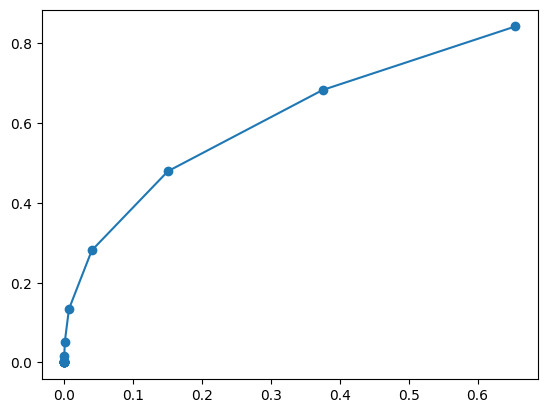

THRESHOLD OF: 0.3200000000000001
arr1: 2000
arr2: 3282
newarr1: 284
newarr2: 104
newarr3: 1716
newarr4: 3178
newavg1= 0.1451243360056542  newstd1= 0.09243171830692172
newavg2= 0.07894227092474407  newstd2= 0.07156595287170951
TP-FP = 1.2263009428210316


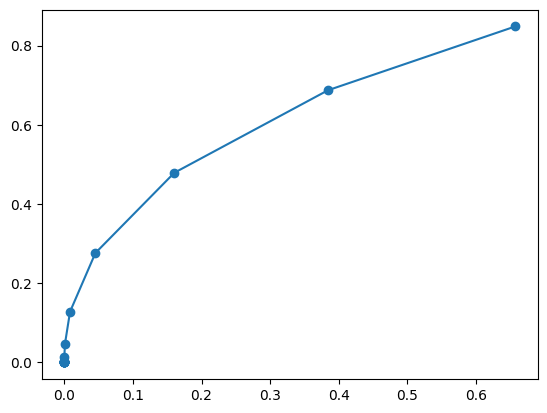

THRESHOLD OF: 0.3300000000000001
arr1: 2000
arr2: 3282
newarr1: 271
newarr2: 95
newarr3: 1729
newarr4: 3187
newavg1= 0.1451243360056542  newstd1= 0.09027308818899925
newavg2= 0.08004084419105975  newstd2= 0.07326163357659016
TP-FP = 1.1917240468927317


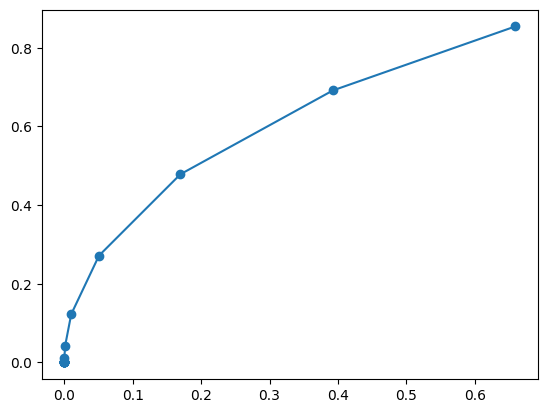

THRESHOLD OF: 0.34000000000000014
arr1: 2000
arr2: 3282
newarr1: 252
newarr2: 89
newarr3: 1748
newarr4: 3193
newavg1= 0.1451243360056542  newstd1= 0.08773875727197396
newavg2= 0.08133351843727972  newstd2= 0.07529095766926698
TP-FP = 1.15125232452242


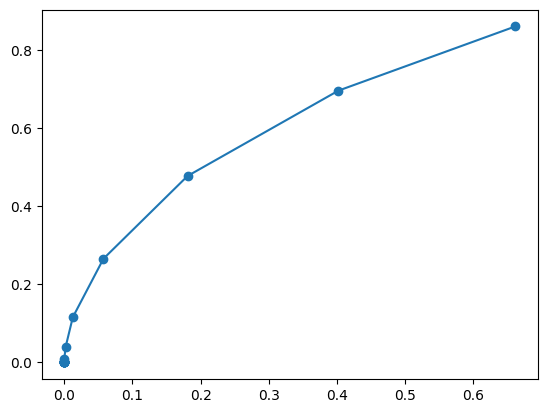

THRESHOLD OF: 0.35000000000000014
arr1: 2000
arr2: 3282
newarr1: 236
newarr2: 85
newarr3: 1764
newarr4: 3197
newavg1= 0.1451243360056542  newstd1= 0.08546952811070391
newavg2= 0.08239486260759003  newstd2= 0.07696877116809557
TP-FP = 1.1177332654594103


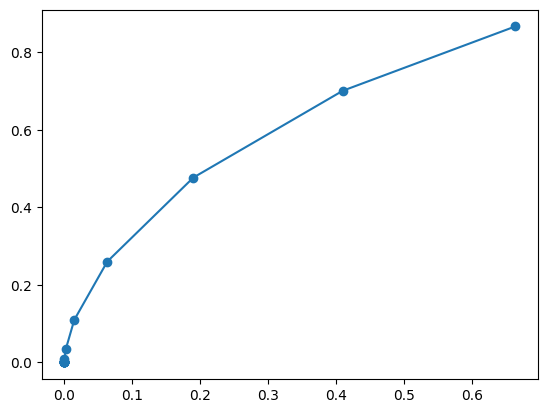

THRESHOLD OF: 0.36000000000000015
arr1: 2000
arr2: 3282
newarr1: 224
newarr2: 79
newarr3: 1776
newarr4: 3203
newavg1= 0.1451243360056542  newstd1= 0.08339432000403763
newavg2= 0.08338018068357282  newstd2= 0.07855177145541149
TP-FP = 1.086877168600127


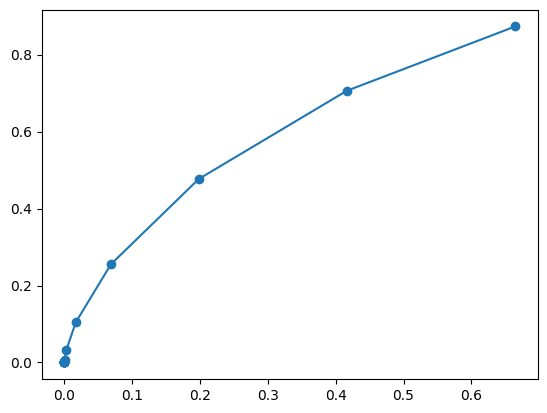

THRESHOLD OF: 0.37000000000000016
arr1: 2000
arr2: 3282
newarr1: 211
newarr2: 76
newarr3: 1789
newarr4: 3206
newavg1= 0.1451243360056542  newstd1= 0.0816236598563396
newavg2= 0.08428459569506042  newstd2= 0.08003233668801277
TP-FP = 1.0590181883214433


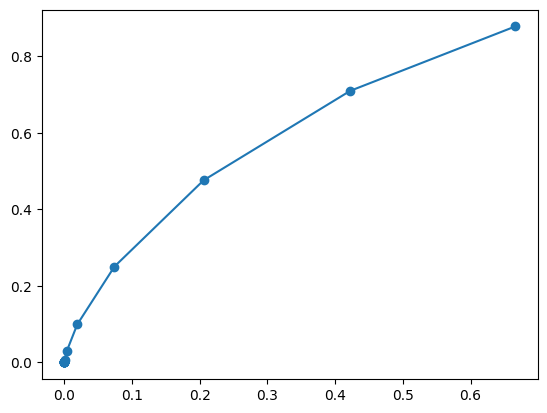

THRESHOLD OF: 0.38000000000000017
arr1: 2000
arr2: 3282
newarr1: 194
newarr2: 72
newarr3: 1806
newarr4: 3210
newavg1= 0.1451243360056542  newstd1= 0.07906454296745273
newavg2= 0.08549882352620992  newstd2= 0.08203093664870804
TP-FP = 1.0214688152550087


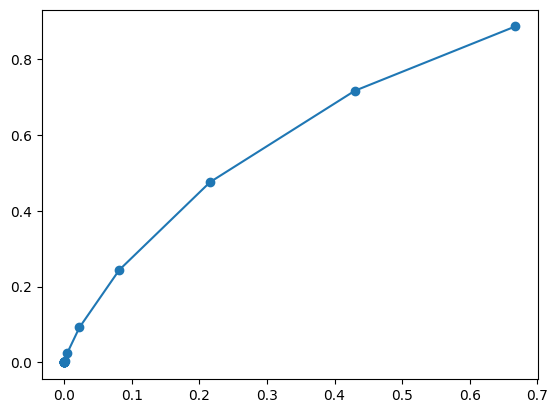

THRESHOLD OF: 0.3900000000000002
arr1: 2000
arr2: 3282
newarr1: 182
newarr2: 66
newarr3: 1818
newarr4: 3216
newavg1= 0.1451243360056542  newstd1= 0.07671121431196469
newavg2= 0.08656917002576008  newstd2= 0.08381107814736083
TP-FP = 0.9884470804373886


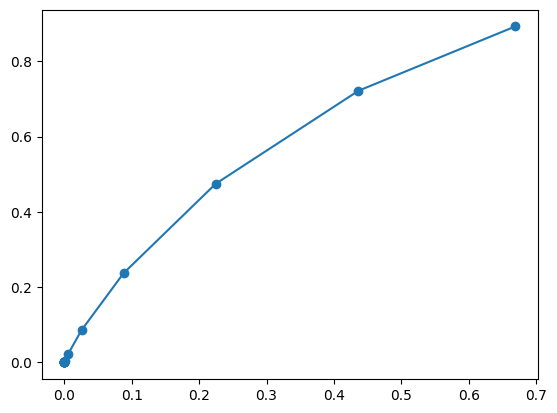

THRESHOLD OF: 0.4000000000000002
arr1: 2000
arr2: 3282
newarr1: 171
newarr2: 65
newarr3: 1829
newarr4: 3217
newavg1= 0.1451243360056542  newstd1= 0.07528190614043322
newavg2= 0.08730646580925748  newstd2= 0.08506258474301119
TP-FP = 0.966208505085935


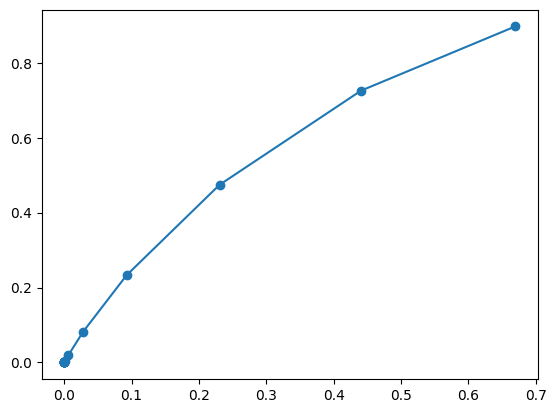

THRESHOLD OF: 0.4100000000000002
arr1: 2000
arr2: 3282
newarr1: 159
newarr2: 60
newarr3: 1841
newarr4: 3222
newavg1= 0.1451243360056542  newstd1= 0.0731694452797558
newavg2= 0.08837328765467001  newstd2= 0.08688611470178773
TP-FP = 0.9341465401309201


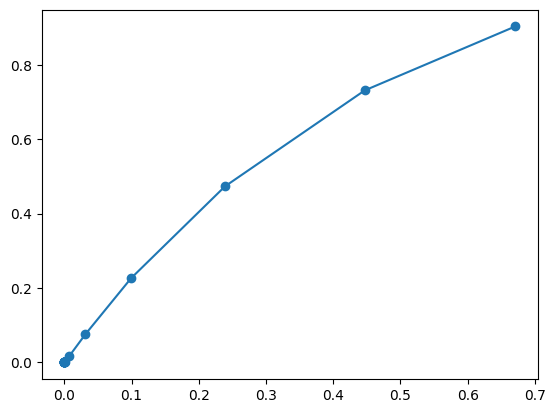

THRESHOLD OF: 0.4200000000000002
arr1: 2000
arr2: 3282
newarr1: 140
newarr2: 58
newarr3: 1860
newarr4: 3224
newavg1= 0.1451243360056542  newstd1= 0.07008955094371594
newavg2= 0.08972066875223296  newstd2= 0.08919501968038894
TP-FP = 0.8933889477234631


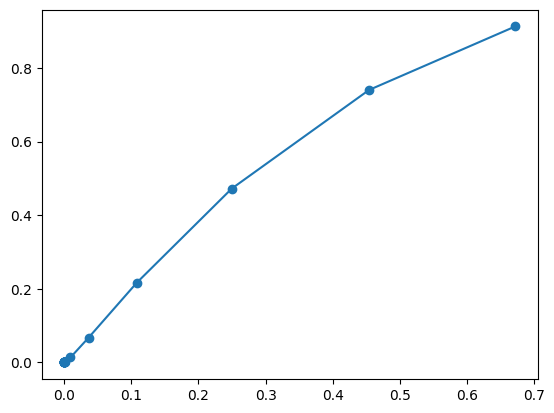

THRESHOLD OF: 0.4300000000000002
arr1: 2000
arr2: 3282
newarr1: 133
newarr2: 54
newarr3: 1867
newarr4: 3228
newavg1= 0.1451243360056542  newstd1= 0.06839424322007455
newavg2= 0.0904454410299147  newstd2= 0.0904509273198791
TP-FP = 0.8716271954330241


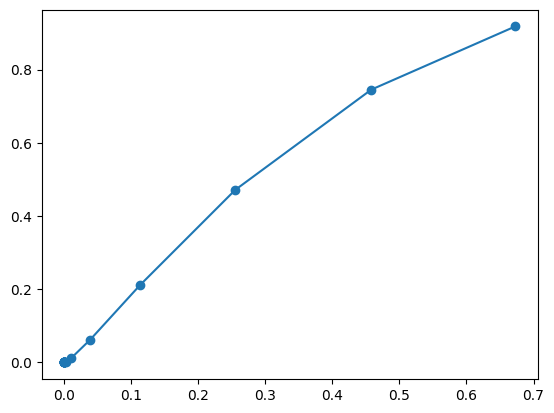

THRESHOLD OF: 0.4400000000000002
arr1: 2000
arr2: 3282
newarr1: 128
newarr2: 49
newarr3: 1872
newarr4: 3233
newavg1= 0.1451243360056542  newstd1= 0.06702803448507443
newavg2= 0.09112185866669564  newstd2= 0.0916431830465443
TP-FP = 0.8517233587157855


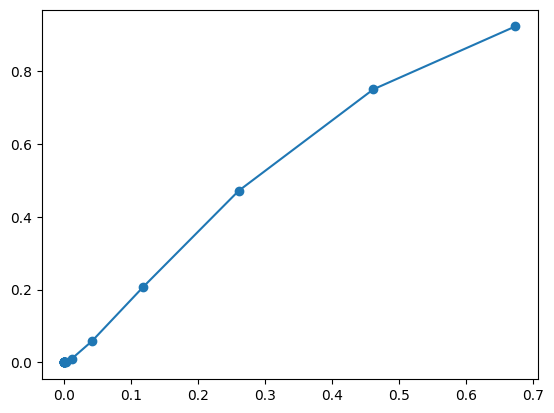

THRESHOLD OF: 0.45000000000000023
arr1: 2000
arr2: 3282
newarr1: 118
newarr2: 45
newarr3: 1882
newarr4: 3237
newavg1= 0.1451243360056542  newstd1= 0.0652334857175171
newavg2= 0.09209154472504598  newstd2= 0.09337234589206743
TP-FP = 0.8235460545236033


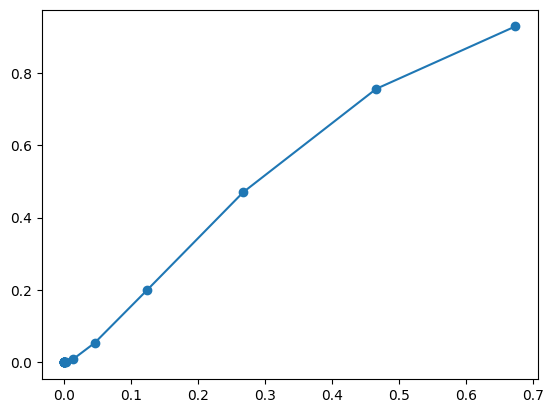

THRESHOLD OF: 0.46000000000000024
arr1: 2000
arr2: 3282
newarr1: 103
newarr2: 41
newarr3: 1897
newarr4: 3241
newavg1= 0.1451243360056542  newstd1= 0.06213185171333148
newavg2= 0.09343142733710165  newstd2= 0.09575947264204535
TP-FP = 0.7843135532695165


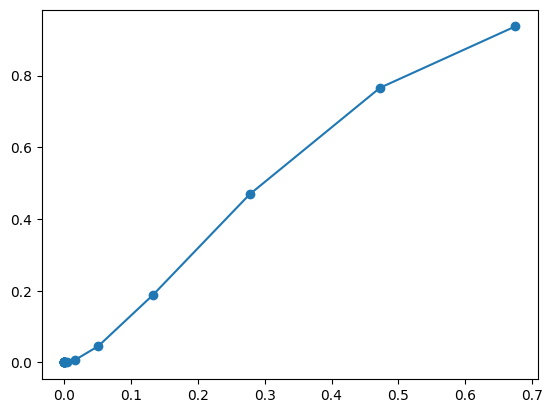

THRESHOLD OF: 0.47000000000000025
arr1: 2000
arr2: 3282
newarr1: 93
newarr2: 37
newarr3: 1907
newarr4: 3245
newavg1= 0.1451243360056542  newstd1= 0.05896200200313716
newavg2= 0.09443602163629514  newstd2= 0.09754669702554873
TP-FP = 0.7546007695203429


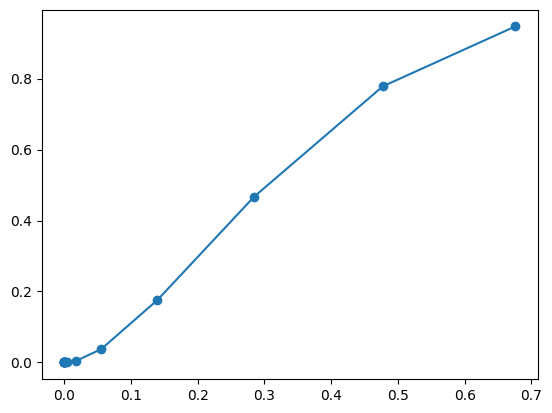

THRESHOLD OF: 0.48000000000000026
arr1: 2000
arr2: 3282
newarr1: 86
newarr2: 32
newarr3: 1914
newarr4: 3250
newavg1= 0.1451243360056542  newstd1= 0.05583019127449406
newavg2= 0.09531813290216877  newstd2= 0.09913293999564095
TP-FP = 0.7287483683714069


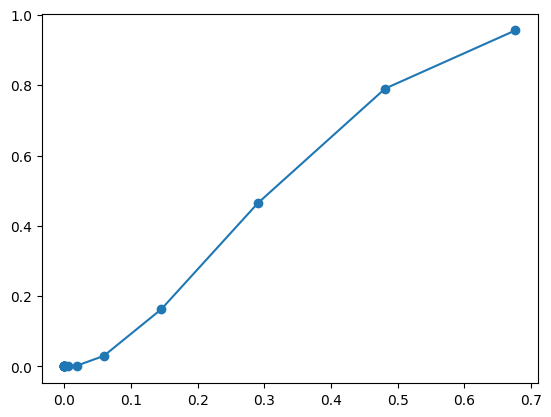

THRESHOLD OF: 0.49000000000000027
arr1: 2000
arr2: 3282
newarr1: 80
newarr2: 31
newarr3: 1920
newarr4: 3251
newavg1= 0.1451243360056542  newstd1= 0.05398551096948435
newavg2= 0.09584528747121143  newstd2= 0.1000951859784923
TP-FP = 0.7135318085456612


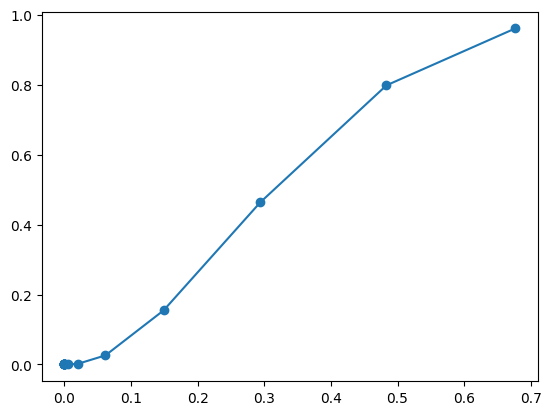

THRESHOLD OF: 0.5000000000000002
arr1: 2000
arr2: 3282
newarr1: 78
newarr2: 28
newarr3: 1922
newarr4: 3254
newavg1= 0.1451243360056542  newstd1= 0.05289893109106183
newavg2= 0.09623097247081353  newstd2= 0.1008127545246918
TP-FP = 0.702577136429634


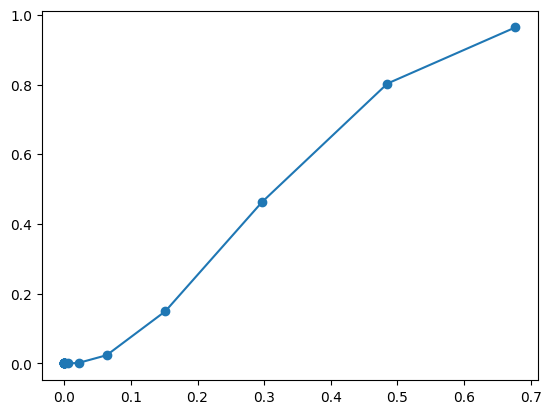

THRESHOLD OF: 0.5100000000000002
arr1: 2000
arr2: 3282
newarr1: 70
newarr2: 25
newarr3: 1930
newarr4: 3257
newavg1= 0.1451243360056542  newstd1= 0.050758838918566945
newavg2= 0.0970981647232657  newstd2= 0.102447692719556
TP-FP = 0.678168579290245


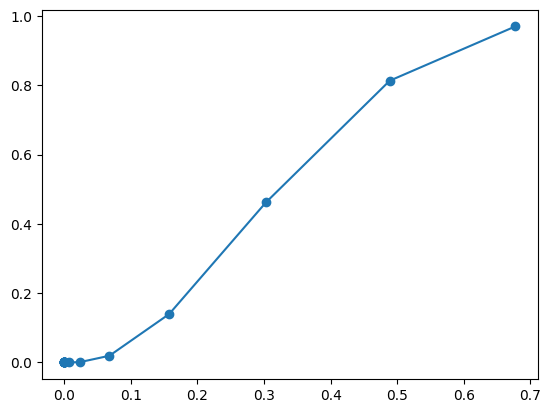

THRESHOLD OF: 0.5200000000000002
arr1: 2000
arr2: 3282
newarr1: 63
newarr2: 24
newarr3: 1937
newarr4: 3258
newavg1= 0.1451243360056542  newstd1= 0.04914593328652286
newavg2= 0.09774125427674571  newstd2= 0.1036702357729559
TP-FP = 0.6601461804848778


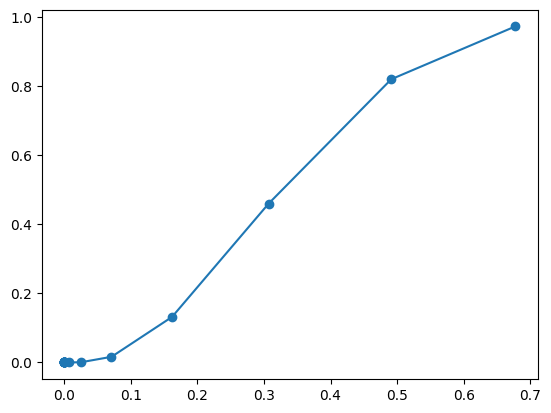

THRESHOLD OF: 0.5300000000000002
arr1: 2000
arr2: 3282
newarr1: 52
newarr2: 23
newarr3: 1948
newarr4: 3259
newavg1= 0.1451243360056542  newstd1= 0.04658027784660061
newavg2= 0.09872613379823708  newstd2= 0.10555889985380722
TP-FP = 0.6326427062671138


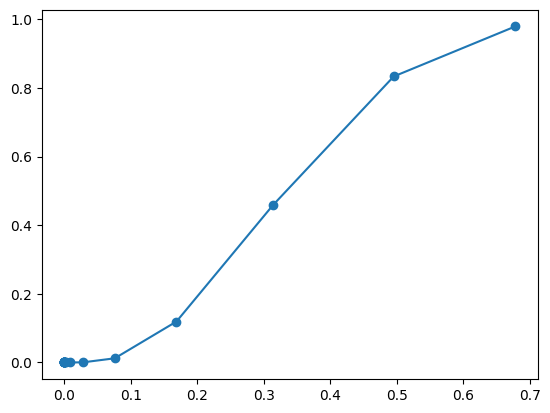

THRESHOLD OF: 0.5400000000000003
arr1: 2000
arr2: 3282
newarr1: 47
newarr2: 20
newarr3: 1953
newarr4: 3262
newavg1= 0.1451243360056542  newstd1= 0.04451302931079929
newavg2= 0.09939532173567113  newstd2= 0.10685067939494494
TP-FP = 0.6139906439429423


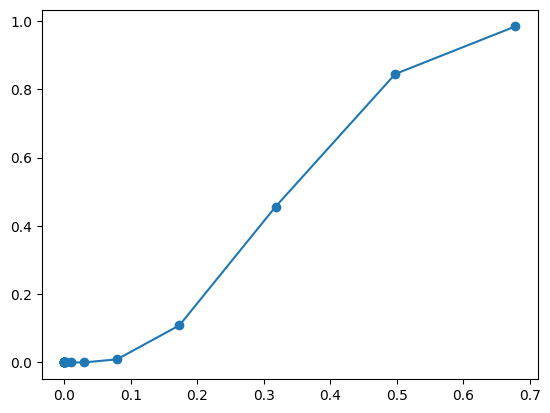

THRESHOLD OF: 0.5500000000000003
arr1: 2000
arr2: 3282
newarr1: 38
newarr2: 19
newarr3: 1962
newarr4: 3263
newavg1= 0.1451243360056542  newstd1= 0.0419118395537712
newavg2= 0.10025204164452815  newstd2= 0.10852647141428017
TP-FP = 0.5901501011572288


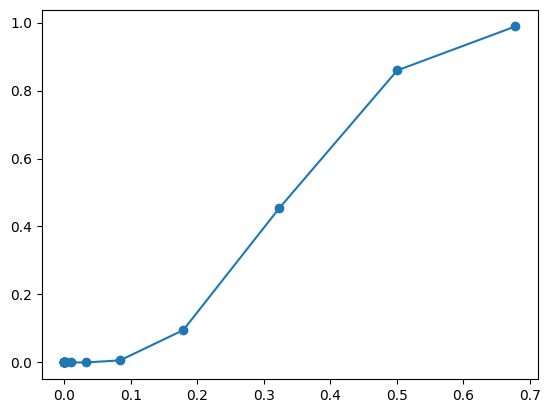

THRESHOLD OF: 0.5600000000000003
arr1: 2000
arr2: 3282
newarr1: 34
newarr2: 18
newarr3: 1966
newarr4: 3264
newavg1= 0.1451243360056542  newstd1= 0.04016600591397609
newavg2= 0.10068633026313428  newstd2= 0.10937931403478522
TP-FP = 0.5780736214573117


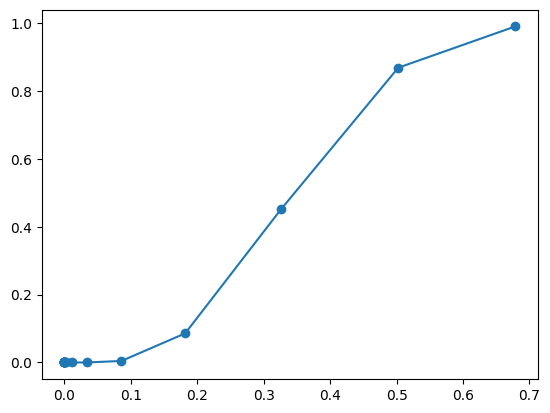

THRESHOLD OF: 0.5700000000000003
arr1: 2000
arr2: 3282
newarr1: 30
newarr2: 16
newarr3: 1970
newarr4: 3266
newavg1= 0.1451243360056542  newstd1= 0.03821060681012352
newavg2= 0.10121783974912726  newstd2= 0.11043722279729587
TP-FP = 0.563267057088225


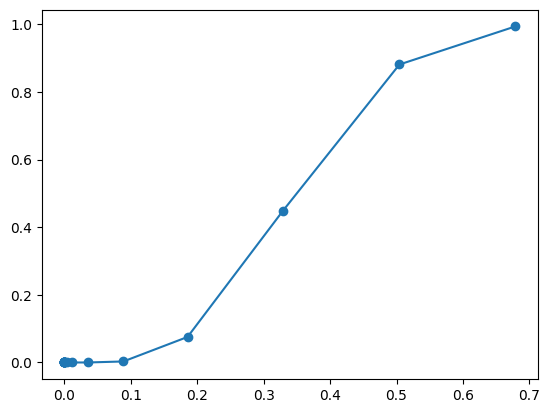

In [129]:
#Attempting to find the Top 2 values in the array
#import heapq
#top2 = heapq.nlargest(2,A1)
#i = min(top2)
#while i > 0:
#   method_2_through(A1,A2,i)
#    i=i-0.01

#Original Code
i = 0.01
while i <= 0.58:
  method_2_through(A1,A2,i)
  i=i+0.01

## Method 1 is Method 2 with threshold t set to 0: P_arr is TPRs and N_arr is FPRs

In [130]:
method_2_through(A1,A2,0)
#ORIGINAL array without repopulating correct ROC CURVE

THRESHOLD OF: 0
arr1: 2000
arr2: 3282
newarr1: 2000
newarr2: 3282
newarr3: 0
newarr4: 0


ZeroDivisionError: division by zero

In [ ]:
newavg1 = getavg(A1)
newstd1 = getstd(A1)
coord1 = getcoord(newavg1,newstd1)
newavg2 = getstd(A2)
newstd2 = getstd(A2)
coord2 = getcoord(newavg2,newstd2)

In [ ]:
from kneed import KneeLocator, DataGenerator as dg
print('newavg1=', newavg1, ' newstd1=', newstd1)
print('newavg2=', newavg2, ' newstd2=', newstd2)
kl = KneeLocator(coord2, coord1, curve="concave")
kl.plot_knee()

In [ ]:
#method 3 , knee locator based on softmax prediction values

In [ ]:
w, h = 10, 500
arr = [[0 for x in range(w)] for y in range(h)]

In [ ]:
for i in range(500):
  for j in range(10):
    arr[i][j] = softmax_preds[i][0][j]

In [ ]:
for i in range(500):
  arr[i].sort()

xarr = [0,1,2,3,4,5,6,7,8,9]

In [ ]:
for i in range(500):
  kj = KneeLocator(xarr,arr[i], curve = "convex",direction="increasing")
  kj.plot_knee()

In [ ]:
#this function repopulates array 1 and 2 based on a new threshold of t
def updated_new_t_val(arr1, arr2, t):
  #TRUE POSITIVES THOSE IN ARRAY 1 WITH A VALUE >= THE THRESHOLD
    newarr1=[]
  #FALSE POSITIVES THOSE IN ARRAY 2 WITH A VALUE < THRESHOLD I
    newarr2=[]
  #FALSE NEGATIVES THOSE IN ARRAY 1 LESS THAN THRESHOLD I
    newarr3=[]
  #TRUE NEGATIVES THOSE IN ARRAY2 WITH A VALUE < THAN I
    newarr4=[]

    for i in range(len(arr2)):
        newarr2.append(arr2[i])

    for i in range(len(arr1)):
        if arr1[i] < t:
            newarr2.append(arr1[i])
        else:
            newarr1.append(arr1[i])

    return newarr1,newarr2